# Project: Default risk of Peer-to-Peer (P2P) lending

# Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Preprocessing</a></li>
<li><a href="#eda"> Exploratory Data Analysis (EDA)</a></li>
<li><a href="#conclusions">Feature Engineering </a></li>
<li><a href="#conclusions">Model Building</a></li>
</ul>



## Introduction :

In this project we will be doing credit risk modelling of peer to peer lending Bondora systems.Data for the study has been retrieved from a publicly available data set of a leading European P2P lending platform  ([**Bondora**](https://www.bondora.com/en/public-reports#dataset-file-format)).The retrieved data is a pool of both defaulted and non-defaulted loans from the time period between **1st March 2009** and **27th January 2020**. The data
comprises of demographic and financial information of borrowers, and loan transactions.In P2P lending, loans are typically uncollateralized and lenders seek higher returns as a compensation for the financial risk they take. In addition, they need to make decisions under information asymmetry that works in favor of the borrowers. In order to make rational decisions, lenders want to minimize the risk of default of each lending decision, and realize the return that compensates for the risk.

In this notebook we will preprocess the raw dataset and will create new preprocessed csv that can be used for building credit risk models.

### Importing Libraries :

In [32]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for visualization
import plotly.express as px # for visualization
import matplotlib.pyplot as plt # for visualization
%matplotlib inline

# To display all the columns of dataframe
pd.set_option('display.max_columns', 500)
import warnings
warnings.filterwarnings("ignore")

### Loading Data

In [44]:
df=pd.read_csv('/kaggle/input/bondora-peer-to-peer-lending-loan-data/LoanData_Bondora.csv')

In [45]:
df.shape

(179235, 112)

In [46]:
df['Status'].value_counts()

Late       68574
Current    57774
Repaid     52887
Name: Status, dtype: int64

In [47]:
df.head()

,ReportAsOfEOD,LoanId,LoanNumber,ListedOnUTC,BiddingStartedOn,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,LoanApplicationStartedDate,LoanDate,ContractEndDate,FirstPaymentDate,MaturityDate_Original,MaturityDate_Last,ApplicationSignedHour,ApplicationSignedWeekday,VerificationType,LanguageCode,Age,DateOfBirth,Gender,Country,AppliedAmount,Amount,Interest,LoanDuration,MonthlyPayment,County,City,UseOfLoan,Education,MaritalStatus,NrOfDependants,EmploymentStatus,EmploymentDurationCurrentEmployer,EmploymentPosition,WorkExperience,OccupationArea,HomeOwnershipType,IncomeFromPrincipalEmployer,IncomeFromPension,IncomeFromFamilyAllowance,IncomeFromSocialWelfare,IncomeFromLeavePay,IncomeFromChildSupport,IncomeOther,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,DebtToIncome,FreeCash,MonthlyPaymentDay,ActiveScheduleFirstPaymentReached,PlannedPrincipalTillDate,PlannedInterestTillDate,LastPaymentOn,CurrentDebtDaysPrimary,DebtOccuredOn,CurrentDebtDaysSecondary,DebtOccuredOnForSecondary,ExpectedLoss,LossGivenDefault,ExpectedReturn,ProbabilityOfDefault,DefaultDate,PrincipalOverdueBySchedule,PlannedPrincipalPostDefault,PlannedInterestPostDefault,EAD1,EAD2,PrincipalRecovery,InterestRecovery,RecoveryStage,StageActiveSince,ModelVersion,Rating,EL_V0,Rating_V0,EL_V1,Rating_V1,Rating_V2,Status,Restructured,ActiveLateCategory,WorseLateCategory,CreditScoreEsMicroL,CreditScoreEsEquifaxRisk,CreditScoreFiAsiakasTietoRiskGrade,CreditScoreEeMini,PrincipalPaymentsMade,InterestAndPenaltyPaymentsMade,PrincipalWriteOffs,InterestAndPenaltyWriteOffs,PrincipalBalance,InterestAndPenaltyBalance,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,PreviousEarlyRepaymentsBefoleLoan,PreviousEarlyRepaymentsCountBeforeLoan,GracePeriodStart,GracePeriodEnd,NextPaymentDate,NextPaymentNr,NrOfScheduledPayments,ReScheduledOn,PrincipalDebtServicingCost,InterestAndPenaltyDebtServicingCost,ActiveLateLastPaymentCategory
0,2021-07-20,66AE108B-532B-4BB3-BAB7-0019A46412C1,483449,2016-03-23 16:07:19,2016-03-23 16:07:19,970,1150,5.0,BO965519,False,2016-03-17 12:39:22,2016-03-23,2020-06-26,2016-05-12,2021-04-12,2020-06-26,17,4,4.0,1,53,NaN,1.0,EE,2125.0,2125.0,20.97,60,62.05,NaN,NaN,2,4.0,2.0,0.0,6.0,MoreThan5Years,NaN,15To25Years,1.0,1.0,0.0,301.0,0.0,53.0,0.0,0.0,0.0,354.0,8,485.09,6,26.29,10.92,12,True,630.22,1251.98,2021-06-16,552.0,2020-01-14,630.0,2019-10-28,0.068512,0.58,0.141145,0.122216,2020-01-14,1155.84,1251.98,77.68,1251.98,64.07,96.14,0.0,2.0,2020-03-03 09:27:48.493000000,2.0,C,NaN,NaN,NaN,NaN,C,Late,False,180+,180+,NaN,NaN,NaN,1000.0,969.16,1187.91,0.00,0.00,1155.84,433.60,1.0,500.0,590.95,0.0,0.0,2019-10-28,2020-01-27,NaN,NaN,NaN,NaN,0.00,51.73,31-60
1,2021-07-20,D152382E-A50D-46ED-8FF2-0053E0C86A70,378148,2015-06-25 11:02:28,2015-06-25 11:02:28,1295,0,1705.0,BOA9K172A,False,2015-06-24 12:36:16,2015-06-25,NaN,2015-08-17,2020-07-17,2020-07-17,11,5,1.0,1,50,NaN,1.0,EE,3000.0,3000.0,17.12,60,84.75,NaN,NaN,3,5.0,2.0,0.0,5.0,MoreThan5Years,NaN,MoreThan25Years,7.0,1.0,900.0,0.0,0.0,0.0,0.0,0.0,0.0,900.0,4,736.45,0,30.58,78.80,17,True,1333.51,3000.00,2019-06-19,1918.0,2016-04-18,1979.0,2016-02-17,0.030799,0.65,0.140436,0.036449,2016-06-02,2436.41,2658.82,1078.96,2730.84,2370.77,294.43,0.0,2.0,2019-08-01 14:18:33,1.0,B,NaN,NaN,0.030799,B,B,Late,False,180+,180+,NaN,NaN,NaN,1000.0,563.59,360.07,0.00,0.00,2436.41,2291.82,1.0,1800.0,445.26,3000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.00,47.08,180+
2,2021-07-20,87342E13-66CB-483F-833A-007953E50C78,451831,2016-01-14 10:00:21,2016-01-14 10:00:21,2700,565,5835.0,BO7971663,True,2016-01-07 15:37:16,2016-01-19,2019-10-24,2016-02-22,2021-01-20,2021-01-20,22,3,4.0,1,44,NaN,0.0,EE,10630.0,9100.0,13.67,60,268.57,NaN,NaN,3,4.0,4.0,1.0,5.0,UpTo3Years,NaN,MoreThan25Years,8.0,8.0,600.0,0.0,0.0,0.0,0.0,0.0,600.0,1200.0,7,905.00,3,26.71,349.43,20,True,3348.50,9100.00,2019-10-23,1368.0,2017-10-20,1428.0,2017-08-21,0.023177,0.58,0.113484,0.041344,2017-12-06,0.00,6456.37,1537.37,6723.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179235 entries, 0 to 179234
Data columns (total 112 columns):
 #    Column                                  Non-Null Count   Dtype  
---   ------                                  --------------   -----  
 0    ReportAsOfEOD                           179235 non-null  object 
 1    LoanId                                  179235 non-null  object 
 2    LoanNumber                              179235 non-null  int64  
 3    ListedOnUTC                             179235 non-null  object 
 4    BiddingStartedOn                        179235 non-null  object 
 5    BidsPortfolioManager                    179235 non-null  int64  
 6    BidsApi                                 179235 non-null  int64  
 7    BidsManual                              179235 non-null  float64
 8    UserName                                179235 non-null  object 
 9    NewCreditCustomer                       179235 non-null  bool   
 10   LoanApplicationStartedDate    

In [43]:
# Tampilkan semua kolom saat df.info()
pd.set_option('display.max_info_columns', 200)  # ubah 200 sesuai kebutuhan
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179235 entries, 0 to 179234
Data columns (total 112 columns):
 #    Column                                  Non-Null Count   Dtype  
---   ------                                  --------------   -----  
 0    ReportAsOfEOD                           179235 non-null  object 
 1    LoanId                                  179235 non-null  object 
 2    LoanNumber                              179235 non-null  int64  
 3    ListedOnUTC                             179235 non-null  object 
 4    BiddingStartedOn                        179235 non-null  object 
 5    BidsPortfolioManager                    179235 non-null  int64  
 6    BidsApi                                 179235 non-null  int64  
 7    BidsManual                              179235 non-null  float64
 8    UserName                                179235 non-null  object 
 9    NewCreditCustomer                       179235 non-null  bool   
 10   LoanApplicationStartedDate    

### Data Definitions :

| Feature                                | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|----------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ActiveLateCategory                     | When a loan is in Principal Debt then it will be categorized by Principal Debt days                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| ActiveLateLastPaymentCategory          | Shows how many days has passed since last payment and categorised if it is overdue                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| ActiveScheduleFirstPaymentReached      | Whether the first payment date has been reached according to the active schedule                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Age                                    | The age of the borrower when signing the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Amount                                 | Amount the borrower received on the Primary Market. This is the principal balance of your purchase from Secondary Market                                                                                                                                                                                                                                                                                                                                                                                            |
| AmountOfPreviousLoansBeforeLoan        | Value of previous loans                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| AppliedAmount                          | The amount borrower applied for originally                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| AuctionBidNumber                       | Unique bid number which is accompanied by Auction number                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| AuctionId                              | A unique number given to all auctions                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| AuctionName                            | Name of the Auction, in newer loans it is defined by the purpose of the loan                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| AuctionNumber                          | Unique auction number which is accompanied by Bid number                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| BidPrincipal                           | On Primary Market BidPrincipal is the amount you made your bid on. On Secondary Market BidPrincipal is the purchase price                                                                                                                                                                                                                                                                                                                                                                                           |
| BidsApi                                | The amount of investment offers made via Api                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| BidsManual                             | The amount of investment offers made manually                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| BidsPortfolioManager                   | The amount of investment offers made by Portfolio Managers                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| BoughtFromResale_Date                  | The time when the investment was purchased from the Secondary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| City                                   | City of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ContractEndDate                        | The date when the loan contract ended                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| Country                                | Residency of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| County                                 | County of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| CreditScoreEeMini                      | 1000 No previous payments problems 900 Payments problems finished 24-36 months ago 800 Payments problems finished 12-24 months ago 700 Payments problems finished 6-12 months ago 600 Payment problems finished < 6 months ago 500 Active payment problems                                                                                                                                                                                                                                                          |
| CreditScoreEsEquifaxRisk               | Generic score for the loan applicants that do not have active past due operations in ASNEF; a measure of the probability of default one year ahead; the score is given on a 6-grade scale: AAA (“Very low”), AA (“Low”), A (“Average”), B (“Average High”), C (“High”), D (“Very High”).                                                                                                                                                                                                                            |
| CreditScoreEsMicroL                    | A score that is specifically designed for risk classifying subprime borrowers (defined by Equifax as borrowers that do not have access to bank loans); a measure of the probability of default one month ahead; the score is given on a 10-grade scale, from the best score to the worst: M1, M2, M3, M4, M5, M6, M7, M8, M9, M10.                                                                                                                                                                                  |
| CreditScoreFiAsiakasTietoRiskGrade     | Credit Scoring model for Finnish Asiakastieto RL1 Very low risk 01-20 RL2 Low risk 21-40 RL3 Average risk 41-60 RL4 Big risk 61-80 RL5 Huge risk 81-100                                                                                                                                                                                                                                                                                                                                                             |
| CurrentDebtDaysPrimary                 | How long the loan has been in Principal Debt                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| CurrentDebtDaysSecondary               | How long the loan has been in Interest Debt                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| DateOfBirth                            | The date of the borrower's birth                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| DebtOccuredOn                          | The date when Principal Debt occurred                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| DebtOccuredOnForSecondary              | The date when Interest Debt occurred                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| DebtToIncome                           | Ratio of borrower's monthly gross income that goes toward paying loans                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| DefaultDate                            | The date when loan went into defaulted state and collection process was started                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| DesiredDiscountRate                    | Investment being sold at a discount or premium                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| EAD1                                   | Exposure at default, outstanding principal at default                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| EAD2                                   | Exposure at default, loan amount less all payments prior to default                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Education                              | 1 Primary education 2 Basic education 3 Vocational education 4 Secondary education 5 Higher education                                                                                                                                                                                                                                                                                                                                                                                                               |
| EL_V0                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EL_V1                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EL_V2                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EmploymentDurationCurrentEmployer      | Employment time with the current employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| EmploymentPosition                     | Employment position with the current employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| EmploymentStatus                       | 1 Unemployed 2 Partially employed 3 Fully employed 4 Self-employed 5 Entrepreneur 6 Retiree                                                                                                                                                                                                                                                                                                                                                                                                                         |
| ExistingLiabilities                    | Borrower's number of existing liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| ExpectedLoss                           | Expected Loss calculated by the current Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ExpectedReturn                         | Expected Return calculated by the current Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| FirstPaymentDate                       | First payment date according to initial loan schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| FreeCash                               | Discretionary income after monthly liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| Gender                                 | 0 Male 1 Woman 2 Undefined                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| GracePeriodEnd                         | Date of the end of Grace period                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| GracePeriodStart                       | Date of the beginning of Grace period                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| HomeOwnershipType                      | 0 Homeless 1 Owner 2 Living with parents 3 Tenant, pre-furnished property 4 Tenant, unfurnished property 5 Council house 6 Joint tenant 7 Joint ownership 8 Mortgage 9 Owner with encumbrance 10 Other                                                                                                                                                                                                                                                                                                              |
| IncomeFromChildSupport                 | Borrower's income from alimony payments                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| IncomeFromFamilyAllowance              | Borrower's income from child support                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| IncomeFromLeavePay                     | Borrower's income from paternity leave                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| IncomeFromPension                      | Borrower's income from pension                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| IncomeFromPrincipalEmployer            | Borrower's income from its employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| IncomeFromSocialWelfare                | Borrower's income from social support                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| IncomeOther                            | Borrower's income from other sources                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| IncomeTotal                            | Borrower's total income                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| Interest                               | Maximum interest rate accepted in the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| InterestAndPenaltyBalance              | Unpaid interest and penalties                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| InterestAndPenaltyDebtServicingCost    | Service cost related to the recovery of the debt based on the interest and penalties of the investment                                                                                                                                                                                                                                                                                                                                                                                                              |
| InterestAndPenaltyPaymentsMade         | Note owner received loan transfers earned interest, penalties total amount                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| InterestAndPenaltyWriteOffs            | Interest that was written off on the investment                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| InterestLateAmount                     | Interest debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| InterestRecovery                       | Interest recovered due to collection process from in debt loans                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LanguageCode                           | 1 Estonian 2 English 3 Russian 4 Finnish 5 German 6 Spanish 9 Slovakian                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| LastPaymentOn                          | The date of the current last payment received from the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LiabilitiesTotal                       | Total monthly liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| ListedOnUTC                            | Date when the loan application appeared on Primary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| LoanDate                               | Date when the loan was issued                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| LoanDuration                           | Current loan duration in months                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LoanId                                 | A unique ID given to all loan applications                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| LoanNumber                             | A unique number given to all loan applications                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| LoanStatusActiveFrom                   | How long the current status has been active                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| LossGivenDefault                       | Gives the percentage of outstanding exposure at the time of default that an investor is likely to lose if a loan actually defaults. This means the proportion of funds lost for the investor after all expected recovery and accounting for the time value of the money recovered. In general, LGD parameter is intended to be estimated based on the historical recoveries. However, in new markets where limited experience does not allow us more precise loss given default estimates, a LGD of 90% is assumed. |
| MaritalStatus                          | 1 Married 2 Cohabitant 3 Single 4 Divorced 5 Widow                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| MaturityDate_Last                      | Loan maturity date according to the current payment schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| MaturityDate_Original                  | Loan maturity date according to the original loan schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| ModelVersion                           | The version of the Rating model used for issuing the Bondora Rating                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| MonthlyPayment                         | Estimated amount the borrower has to pay every month                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| MonthlyPaymentDay                      | The day of the month the loan payments are scheduled for The actual date is adjusted for weekends and bank holidays (e.g. if 10th is Sunday then the payment will be made on the 11th in that month)                                                                                                                                                                                                                                                                                                                |
| NewCreditCustomer                      | Did the customer have prior credit history in Bondora 0 Customer had at least 3 months of credit history in Bondora 1 No prior credit history in Bondora                                                                                                                                                                                                                                                                                                                                                            |
| NextPaymentDate                        | According to schedule the next date for borrower to make their payment                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| NextPaymentNr                          | According to schedule the number of the next payment                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NextPaymentSum                         | According to schedule the amount of the next payment                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NoOfPreviousLoansBeforeLoan            | Number of previous loans                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| note_id                                | A unique ID given to the investments                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NoteLoanLateChargesPaid                | The amount of late charges the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| NoteLoanTransfersInterestAmount        | The amount of interest the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| NoteLoanTransfersMainAmount            | The amount of principal the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| NrOfDependants                         | Number of children or other dependants                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| NrOfScheduledPayments                  | According to schedule the count of scheduled payments                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| OccupationArea                         | 1 Other 2 Mining 3 Processing 4 Energy 5 Utilities 6 Construction 7 Retail and wholesale 8 Transport and warehousing 9 Hospitality and catering 10 Info and telecom 11 Finance and insurance 12 Real-estate 13 Research 14 Administrative 15 Civil service & military 16 Education 17 Healthcare and social help 18 Art and entertainment 19 Agriculture, forestry and fishing                                                                                                                                      |
| OnSaleSince                            | Time when the investment was added to Secondary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| PenaltyLateAmount                      | Late charges debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| PlannedInterestPostDefault             | The amount of interest that was planned to be received after the default occurred                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| PlannedInterestTillDate                | According to active schedule the amount of interest the investment should have received                                                                                                                                                                                                                                                                                                                                                                                                                             |
| PlannedPrincipalPostDefault            | The amount of principal that was planned to be received after the default occurred                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| PlannedPrincipalTillDate               | According to active schedule the amount of principal the investment should have received                                                                                                                                                                                                                                                                                                                                                                                                                            |
| PreviousEarlyRepaymentsBeforeLoan      | How much was the early repayment amount before the loan                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| PreviousEarlyRepaymentsCountBeforeLoan | How many times the borrower had repaid early                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| PreviousRepaymentsBeforeLoan           | How much the borrower had repaid before the loan                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| PrincipalBalance                       | Principal that still needs to be paid by the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| PrincipalDebtServicingCost             | Service cost related to the recovery of the debt based on the principal of the investment                                                                                                                                                                                                                                                                                                                                                                                                                           |
| PrincipalLateAmount                    | Principal debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| PrincipalOverdueBySchedule             | According to the current schedule, principal that is overdue                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| PrincipalPaymentsMade                  | Note owner received loan transfers principal amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| PrincipalRecovery                      | Principal recovered due to collection process from in debt loans                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| PrincipalWriteOffs                     | Principal that was written off on the investment                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| ProbabilityOfDefault                   | Probability of Default, refers to a loan’s probability of default within one year horizon.                                                                                                                                                                                                                                                                                                                                                                                                                          |
| PurchasePrice                          | Investment amount or secondary market purchase price                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Rating                                 | Bondora Rating issued by the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Rating_V0                              | Bondora Rating issued by version 0 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Rating_V1                              | Bondora Rating issued by version 1 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Rating_V2                              | Bondora Rating issued by version 2 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| RecoveryStage                          | Current stage according to the recovery model 1 Collection 2 Recovery 3 Write Off                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| RefinanceLiabilities                   | The total amount of liabilities after refinancing                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| ReScheduledOn                          | The date when the a new schedule was assigned to the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Restructured                           | The original maturity date of the loan has been increased by more than 60 days                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| SoldInResale_Date                      | The date when the investment was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| SoldInResale_Price                     | The price of the investment that was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| SoldInResale_Principal                 | The principal remaining of the investment that was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| StageActiveSince                       | How long the current recovery stage has been active                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Status                                 | The current status of the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| UseOfLoan                              | 0 Loan consolidation 1 Real estate 2 Home improvement 3 Business 4 Education 5 Travel 6 Vehicle 7 Other 8 Health 101 Working capital financing 102 Purchase of machinery equipment 103 Renovation of real estate 104 Accounts receivable financing 105 Acquisition of means of transport 106 Construction finance 107 Acquisition of stocks 108 Acquisition of real estate 109 Guaranteeing obligation 110 Other business All codes in format 1XX are for business loans that are not supported since October 2012  |
| UserName                               | The user name generated by the system for the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| VerificationType                       | Method used for loan application data verification 0 Not set 1 Income unverified 2 Income unverified, cross-referenced by phone 3 Income verified 4 Income and expenses verified                                                                                                                                                                                                                                                                                                                                    |
| WorkExperience                         | Borrower's overall work experience in years                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| WorseLateCategory                      | Displays the last longest period of days when the loan was in Principal Debt                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| XIRR                                   | XIRR (extended internal rate of return) is a methodology to calculate the net return using the loan issued date and amount, loan repayment dates and amounts and the principal balance according to the original repayment date. All overdue principal payments are written off immediately. No provisions for future losses are made & only received (not accrued or scheduled) interest payments are taken into account.                                                                                          |

## Data Preprocessing

#### Percentage of Missing Values

It might be helpful to see what percentage of the values in our dataset were missing to give us a better sense of the scale of this problem:

In [49]:
# how many total missing values do we have?
total_cells = np.product(df.shape)
total_missing = df.isnull().sum().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

26.27224732892571


We can notice that almost a quarter of the cells in this dataset are empty! In the next step, we're going to take a closer look at all of the columns with missing values and try to figure out what might be going on with them.

In [50]:
# Finding columns with a mean null values percentage above 40%
DropColList = df.columns[(df.isnull().mean()*100) >= 40].tolist()

In [51]:
# Displying columns with a mean null values percentage above 40%
df[DropColList].isnull().mean()*100

ContractEndDate                         42.535777
DateOfBirth                            100.000000
County                                 100.000000
City                                   100.000000
NrOfDependants                          80.137808
EmploymentPosition                     100.000000
WorkExperience                          79.623399
PlannedPrincipalTillDate                69.613078
CurrentDebtDaysPrimary                  57.472592
DebtOccuredOn                           57.472592
CurrentDebtDaysSecondary                54.100483
DebtOccuredOnForSecondary               54.100483
DefaultDate                             60.155104
PlannedPrincipalPostDefault             60.155662
PlannedInterestPostDefault              60.155662
EAD1                                    60.156219
EAD2                                    60.156219
PrincipalRecovery                       60.155662
InterestRecovery                        60.155662
EL_V0                                   97.450833


In [52]:
# Number of these columns
len(df.columns[(df.isnull().mean()*100) >= 40])

38

Removing all the features which have more than 40% missing values

In [53]:
# Now we can remove columns having more than 40% missing values
df.drop(columns= DropColList, axis= 1, inplace=True)

In [54]:
df.shape

(179235, 74)

In [55]:
df['NrOfScheduledPayments'].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: NrOfScheduledPayments, dtype: float64

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179235 entries, 0 to 179234
Data columns (total 74 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ReportAsOfEOD                           179235 non-null  object 
 1   LoanId                                  179235 non-null  object 
 2   LoanNumber                              179235 non-null  int64  
 3   ListedOnUTC                             179235 non-null  object 
 4   BiddingStartedOn                        179235 non-null  object 
 5   BidsPortfolioManager                    179235 non-null  int64  
 6   BidsApi                                 179235 non-null  int64  
 7   BidsManual                              179235 non-null  float64
 8   UserName                                179235 non-null  object 
 9   NewCreditCustomer                       179235 non-null  bool   
 10  LoanApplicationStartedDate              1792

Let's remove features such as “Loan ID”, “Loan number”, “UserName”, and "DateOfBirth"(because age is already present), since they are assigned to each loan (or borrower) mainly for data storage and identification purposes and are meaningless for default prediction.

As IncomeTotal is persent, we can drop "IncomeFromPrincipalEmployer", "IncomeFromPension",
"IncomeFromFamilyAllowance", "IncomeFromSocialWelfare","IncomeFromLeavePay", "IncomeFromChildSupport", and "IncomeOther" columns

In [58]:
df.drop(columns=['IncomeFromPrincipalEmployer', 'IncomeFromPension', 'IncomeFromFamilyAllowance', 'IncomeFromSocialWelfare',
                 'IncomeFromLeavePay', 'IncomeFromChildSupport', 'IncomeOther'], inplace = True)

Let's remove unnecessary date features as we don't work on a time series study

In [59]:
df.drop(columns=['ReportAsOfEOD', 'ListedOnUTC', 'BiddingStartedOn', 'LoanApplicationStartedDate', 'LastPaymentOn',
                 'MonthlyPaymentDay','LoanDate', 'FirstPaymentDate', 'MaturityDate_Original','MaturityDate_Last'], 
        inplace = True)

Let's Remove other features that have no effecto on our analysis

In [60]:
df.drop(columns=['NextPaymentNr', 'NrOfScheduledPayments', 'ApplicationSignedHour', 'ApplicationSignedWeekday', 
                 'ActiveScheduleFirstPaymentReached', 'PlannedInterestTillDate', 'ExpectedLoss','LossGivenDefault',
                'ExpectedReturn', 'ProbabilityOfDefault', 'PrincipalOverdueBySchedule', 'StageActiveSince', 
                'ModelVersion', 'WorseLateCategory'], inplace = True)

In [61]:
df.shape

(179235, 43)

#### Creating Target Variable

Here, status is the variable which help us in creating target variable. The reason for not making status as target variable is that it has three unique values **current, Late and repaid**. There is no default feature but there is a feature **default date** which tells us when the borrower has defaulted means on which date the borrower defaulted. So, we will be combining **Status** and **Default date** features for creating target  variable.The reason we cannot simply treat Late as default because it also has some records in which actual status is Late but the user has never defaulted i.e., default date is null.
So we will first filter out all the current status records because they are not matured yet they are current loans. 

Now, we will create new target variable in which 0 will be assigned when default date is null means borrower has never defaulted while 1 in case default date is present.

In [63]:
# Add DefaultDate Column to our df dataset
df["DefaultDate"] = pd.read_csv('/kaggle/input/bondora-peer-to-peer-lending-loan-data/LoanData_Bondora.csv',low_memory=False).DefaultDate

In [64]:
# let's find the counts of each status categories 
df.Status.value_counts()

Late       68574
Current    57774
Repaid     52887
Name: Status, dtype: int64

In [65]:
# filtering out Current Status records
df = df[df.Status != 'Current']

In [66]:
df.Status.value_counts()

Late      68574
Repaid    52887
Name: Status, dtype: int64

In [67]:
df.shape

(121461, 44)

In [69]:
# Rplace any null value by NoDefault in DefaultDate column
df.DefaultDate.fillna('NoDefault', inplace = True)

In [70]:
# Replace any Date by Defalut
for i in range(len(df.DefaultDate.values)):
    if df.DefaultDate.values[i] != 'NoDefault':
        df.DefaultDate.values[i] = 'Default'

In [71]:
# check the counts of default and nondefault 
df.DefaultDate.value_counts()

Default      71253
NoDefault    50208
Name: DefaultDate, dtype: int64

In [72]:
# let's drop the status columns
df.drop(columns=['Status'], inplace = True)

In [73]:
df.head()

,LoanId,LoanNumber,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,VerificationType,LanguageCode,Age,Gender,Country,AppliedAmount,Amount,Interest,LoanDuration,MonthlyPayment,UseOfLoan,Education,MaritalStatus,EmploymentStatus,EmploymentDurationCurrentEmployer,OccupationArea,HomeOwnershipType,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,DebtToIncome,FreeCash,RecoveryStage,Rating,Restructured,CreditScoreEsMicroL,PrincipalPaymentsMade,InterestAndPenaltyPaymentsMade,PrincipalBalance,InterestAndPenaltyBalance,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,DefaultDate
0,66AE108B-532B-4BB3-BAB7-0019A46412C1,483449,970,1150,5.0,BO965519,False,4.0,1,53,1.0,EE,2125.0,2125.0,20.97,60,62.05,2,4.0,2.0,6.0,MoreThan5Years,1.0,1.0,354.0,8,485.09,6,26.29,10.92,2.0,C,False,NaN,969.16,1187.91,1155.84,433.60,1.0,500.0,590.95,0.0,Default
1,D152382E-A50D-46ED-8FF2-0053E0C86A70,378148,1295,0,1705.0,BOA9K172A,False,1.0,1,50,1.0,EE,3000.0,3000.0,17.12,60,84.75,3,5.0,2.0,5.0,MoreThan5Years,7.0,1.0,900.0,4,736.45,0,30.58,78.80,2.0,B,False,NaN,563.59,360.07,2436.41,2291.82,1.0,1800.0,445.26,1.0,Default
2,87342E13-66CB-483F-833A-007953E50C78,451831,2700,565,5835.0,BO7971663,True,4.0,1,44,0.0,EE,10630.0,9100.0,13.67,60,268.57,3,4.0,4.0,5.0,UpTo3Years,8.0,8.0,1200.0,7,905.00,3,26.71,349.43,2.0,A,False,NaN,6537.00,1708.47,0.00,0.00,0.0,0.0,0.00,0.0,Default
3,87227056-6BF9-410C-98D1-008F788E122A,349381,1115,0,385.0,BO76151K3,True,3.0,6,42,0.0,ES,1500.0,1500.0,40.40,60,63.53,2,2.0,1.0,3.0,UpTo5Years,1.0,2.0,863.0,1,350.00,0,7.36,449.47,1.0,F,False,M3,464.73,355.92,1035.27,2833.83,0.0,0.0,0.00,1.0,Default
4,2DDE6336-E466-4624-A337-00A0ED1A1468,443082,305,0,785.0,BOK423A63,True,4.0,6,34,1.0,ES,1595.0,1090.0,68.39,48,101.19,7,4.0,4.0,6.0,UpTo1Year,1.0,3.0,697.0,5,940.00,2,36.04,95.81,1.0,HR,False,M5,0.01,0.00,1089.99,4215.37,0.0,0.0,0.00,0.0,Default


Now, we will rename DefaultDate taarget column to "LoanStatus", so "LoanStatus" is our target variable

In [75]:
# Rename DefaultDate column to LoanStatus
df.rename(columns={'DefaultDate':'LoanStatus'}, inplace = True)

In [76]:
df.LoanStatus.value_counts()

Default      71253
NoDefault    50208
Name: LoanStatus, dtype: int64

#### Checking datatype of all features
In this step we will see any data type mismatch

In [77]:
# write your code here
df.dtypes

LoanId                                     object
LoanNumber                                  int64
BidsPortfolioManager                        int64
BidsApi                                     int64
BidsManual                                float64
UserName                                   object
NewCreditCustomer                            bool
VerificationType                          float64
LanguageCode                                int64
Age                                         int64
Gender                                    float64
Country                                    object
AppliedAmount                             float64
Amount                                    float64
Interest                                  float64
LoanDuration                                int64
MonthlyPayment                            float64
UseOfLoan                                   int64
Education                                 float64
MaritalStatus                             float64


- As we can see in numeric column distribution there are many columns which are present as numeric but they are actually categorical as per data description such as Verification Type, Language Code, Gender, Use of Loan, Education, Marital Status,EmployementStatus, OccupationArea etc.
- So we will convert these features to categorical features

- For verification column:

In [78]:
# Replace Null values by 'Not Set'
df.VerificationType.fillna('Not Set', inplace = True)

In [79]:
# convert from float type to string first
df['VerificationType'] = df['VerificationType'].astype(object)

for i in range(len(df.VerificationType.values)):
    df.VerificationType.values[i] = str(df.VerificationType.values[i])

In [80]:
df.VerificationType.dtype, type(df.VerificationType.values[0])

(dtype('O'), str)

In [81]:
# From Bonora dataser we can find that:
# 0 Not set, 1 Income unverified, 2 Income unverified, cross-referenced by phone, 3 Income verified 
df.VerificationType = df.VerificationType.str.replace('0.0', 'Not Set')
df.VerificationType = df.VerificationType.str.replace('1.0', 'Income unverified')
df.VerificationType = df.VerificationType.str.replace('2.0', 'Income unverified,cross-referenced by phone')
df.VerificationType = df.VerificationType.str.replace('3.0', 'Income verified')
df.VerificationType = df.VerificationType.str.replace('4.0', 'Income and expenses verified')

In [82]:
df.VerificationType.value_counts()

Income and expenses verified                   73175
Income unverified                              37435
Income verified                                 8965
Income unverified,cross-referenced by phone     1828
Not Set                                           58
Name: VerificationType, dtype: int64

- For Gender column:

In [83]:
df.Gender.value_counts()

0.0    75449
1.0    34984
2.0    10983
Name: Gender, dtype: int64

In [84]:
# Replace Null values by Undefined
df.Gender.fillna('Undefined', inplace = True)

In [85]:
# Convert from int types to string first
df['Gender'] = df['Gender'].astype(object)

for i in range(len(df.Gender.values)):
    df.Gender.values[i] = str(df.Gender.values[i])

In [86]:
df.Gender.dtype, type(df.Gender.values[0])

(dtype('O'), str)

In [87]:
# From Bonora dataser we can find that:
## 0.0 Male 1.0 Female 2.0 Undefined
df.Gender = df.Gender.str.replace('0.0', 'Male')
df.Gender = df.Gender.str.replace('1.0', 'Female')
df.Gender = df.Gender.str.replace('2.0', 'Undefined')

In [88]:
# Check
df.Gender.value_counts()

Male         75449
Female       34984
Undefined    11028
Name: Gender, dtype: int64

- Let's handle LanguageCode column :

In [89]:
df.LanguageCode.value_counts()

1     53751
4     30771
6     24213
3     11456
2       960
9       294
22        6
5         5
10        1
13        1
7         1
21        1
15        1
Name: LanguageCode, dtype: int64

In [90]:
# Convert from int types to string first
df.LanguageCode = df.LanguageCode.astype(object)

for i in range(len(df.LanguageCode.values)):
    df.LanguageCode.values[i] = str(df.LanguageCode.values[i])

In [91]:
df.LanguageCode.dtype, type(df.LanguageCode.values[0])

(dtype('O'), str)

In [92]:
df.LanguageCode.value_counts()

1     53751
4     30771
6     24213
3     11456
2       960
9       294
22        6
5         5
10        1
13        1
7         1
21        1
15        1
Name: LanguageCode, dtype: int64

In [93]:
# From Bonora dataser we can find that:
## 1 Estonian 2 English 3 Russian 4 Finnish 5 German 6 Spanish 9 Slovakian
### We will give 'Other' to other Language code
#### You should handle 'Other' first
df.LanguageCode = df.LanguageCode.str.replace('7',  'Other')
df.LanguageCode = df.LanguageCode.str.replace('10', 'Other')
df.LanguageCode = df.LanguageCode.str.replace('13', 'Other')
df.LanguageCode = df.LanguageCode.str.replace('15', 'Other')
df.LanguageCode = df.LanguageCode.str.replace('21', 'Other')
df.LanguageCode = df.LanguageCode.str.replace('22', 'Other')
df.LanguageCode = df.LanguageCode.str.replace('1', 'Estonian')
df.LanguageCode = df.LanguageCode.str.replace('2', 'English')
df.LanguageCode = df.LanguageCode.str.replace('3', 'Russian')
df.LanguageCode = df.LanguageCode.str.replace('4', 'Finnish')
df.LanguageCode = df.LanguageCode.str.replace('5', 'German')
df.LanguageCode = df.LanguageCode.str.replace('6', 'Spanish')
df.LanguageCode = df.LanguageCode.str.replace('9', 'Slovakian')

In [94]:
# Check
df.LanguageCode.value_counts()

Estonian     53751
Finnish      30771
Spanish      24213
Russian      11456
English        960
Slovakian      294
Other           11
German           5
Name: LanguageCode, dtype: int64

- Let's handle UseOfLoan column :

In [95]:
df.UseOfLoan.value_counts()

-1      86395
 7       9352
 2       8686
 0       6672
 6       3047
 3       1871
 5       1710
 8       1460
 4       1314
 1        901
 102       21
 110       17
 104        6
 101        5
 107        2
 108        1
 106        1
Name: UseOfLoan, dtype: int64

In [96]:
# Convert from int types to string first
df.UseOfLoan = df.UseOfLoan.astype(object)

for i in range(len(df.UseOfLoan.values)):
    df.UseOfLoan.values[i] = str(df.UseOfLoan.values[i])

In [97]:
df.UseOfLoan.dtype, type(df.UseOfLoan.values[0])

(dtype('O'), str)

In [98]:
# From Bondora dataset and Bondora Statistics Page we can find that:
## -1 Not Set, 0 Loan consolidation , 1 Real estate, 2 Home improvement, 3 Business, 4 Education, 5 Travel, 6 Vehicle, 7 Other,
## 8 Health, 102  Purchase of machinery equipment, 110 Other business, 104 Accounts receivable financing, 
## 101 Working capital financing, 107 Acquisition of stocks, 108 Acquisition of real estate, 106 Acquisition of means of transport

df.UseOfLoan = df.UseOfLoan.str.replace('102', 'Purchase of machinery equipment')
df.UseOfLoan = df.UseOfLoan.str.replace('110', 'Other business')
df.UseOfLoan = df.UseOfLoan.str.replace('104', 'Accounts receivable financing')
df.UseOfLoan = df.UseOfLoan.str.replace('101', 'Working capital financing')
df.UseOfLoan = df.UseOfLoan.str.replace('107', 'Acquisition of stocks')
df.UseOfLoan = df.UseOfLoan.str.replace('106', 'Acquisition of means of transport')
df.UseOfLoan = df.UseOfLoan.str.replace('108', 'Acquisition of real estate')

df.UseOfLoan = df.UseOfLoan.str.replace('-1',  'Not Set')
df.UseOfLoan = df.UseOfLoan.str.replace('0',   'Loan consolidation')
df.UseOfLoan = df.UseOfLoan.str.replace('1',   'Real estate')
df.UseOfLoan = df.UseOfLoan.str.replace('2',   'Home improvement')
df.UseOfLoan = df.UseOfLoan.str.replace('3',   'Business')
df.UseOfLoan = df.UseOfLoan.str.replace('4',   'Education')
df.UseOfLoan = df.UseOfLoan.str.replace('5',   'Travel')
df.UseOfLoan = df.UseOfLoan.str.replace('6',   'Vehicle')
df.UseOfLoan = df.UseOfLoan.str.replace('7',   'Other')
df.UseOfLoan = df.UseOfLoan.str.replace('8',   'Health')

In [99]:
# Check
df.UseOfLoan.value_counts()

Not Set                              86395
Other                                 9352
Home improvement                      8686
Loan consolidation                    6672
Vehicle                               3047
Business                              1871
Travel                                1710
Health                                1460
Education                             1314
Real estate                            901
Purchase of machinery equipment         21
Other business                          17
Accounts receivable financing            6
Working capital financing                5
Acquisition of stocks                    2
Acquisition of real estate               1
Acquisition of means of transport        1
Name: UseOfLoan, dtype: int64

- Let's handle Education column :

In [100]:
# We will replace Null values
df.Education.fillna('Not Present', inplace = True)

In [101]:
df.Education.value_counts()

4.0            44809
5.0            31618
3.0            27431
1.0            11446
2.0             5950
-1.0             149
Not Present       50
0.0                8
Name: Education, dtype: int64

In [103]:
# Convert from int types to string first
df.Education = df.Education.astype(object)

for i in range(len(df.Education.values)):
    df.Education.values[i] = str(df.Education.values[i])

In [104]:
# We will replace 0 and -1 by "Not Present".
## And from Bondora dataset and Bondora Statistics Page we can find that:
## 1 Primary education, 2 Basic education, 3 Vocational education, 4 Secondary education, 5 Higher education.
df.Education = df.Education.str.replace('-1.0',  'Not Present')
df.Education = df.Education.str.replace('0.0',   'Not Present')
df.Education = df.Education.str.replace('1.0',   'Primary education')
df.Education = df.Education.str.replace('2.0',   'Basic education')
df.Education = df.Education.str.replace('3.0',   'Vocational education')
df.Education = df.Education.str.replace('4.0',   'Secondary education')
df.Education = df.Education.str.replace('5.0',   'Higher education')

In [105]:
# Check
df.Education.value_counts()

Secondary education     44809
Higher education        31618
Vocational education    27431
Primary education       11446
Basic education          5950
Not Present               207
Name: Education, dtype: int64

- Let's handle MaritalStatus column :

In [106]:
df.MaritalStatus.value_counts()

-1.0    86395
 3.0    12025
 1.0    10188
 2.0     8965
 4.0     3264
 5.0      566
 0.0        8
Name: MaritalStatus, dtype: int64

In [107]:
# Replace Null values by "Not Specified"
df.MaritalStatus.fillna('Not Specified', inplace = True)

In [ ]:
# Convert from int types to string first
df.MaritalStatus = df.MaritalStatus.astype(object)

for i in range(len(df.MaritalStatus.values)):
    df.MaritalStatus.values[i] = str(df.MaritalStatus.values[i])

In [108]:
# Again Marital status of value 0 and -1 has no description so we will encode them as Not_specified
## And from Bondora dataser:
## 1 Married 2 Cohabitant 3 Single 4 Divorced 5 Widow
df.MaritalStatus = df.MaritalStatus.str.replace('-1.0',  'Not Specified')
df.MaritalStatus = df.MaritalStatus.str.replace('0.0',   'Not Specified')
df.MaritalStatus = df.MaritalStatus.str.replace('1.0',   'Married')
df.MaritalStatus = df.MaritalStatus.str.replace('2.0',   'Cohabitant')
df.MaritalStatus = df.MaritalStatus.str.replace('3.0',   'Single')
df.MaritalStatus = df.MaritalStatus.str.replace('4.0',   'Divorced')
df.MaritalStatus = df.MaritalStatus.str.replace('5.0',   'Widow')

In [109]:
# Check 
df.MaritalStatus.value_counts()

Not Specified    50
Name: MaritalStatus, dtype: int64

- Let's handle EmploymentStatus :

In [110]:
df.EmploymentStatus.value_counts()

-1.0    86395
 3.0    28796
 5.0     1864
 6.0     1762
 4.0     1255
 2.0     1155
 0.0       32
Name: EmploymentStatus, dtype: int64

In [112]:
df.EmploymentStatus.fillna('Not present', inplace = True)

In [113]:
# Convert from int types to string first
df.EmploymentStatus = df.EmploymentStatus.astype(object)

for i in range(len(df.EmploymentStatus.values)):
    df.EmploymentStatus.values[i] = str(df.EmploymentStatus.values[i])

In [114]:
# Again EmploymentStatus of value 0 and -1 has no description so we will encode them as Not present
## And from Bondora dataser:
## 1 Unemployed 2 Partially employed 3 Fully employed 4 Self-employed 5 Entrepreneur 6 Retiree
df.EmploymentStatus = df.EmploymentStatus.str.replace('-1.0',  'Not present')
df.EmploymentStatus = df.EmploymentStatus.str.replace('0.0',   'Not present')
df.EmploymentStatus = df.EmploymentStatus.str.replace('2.0',   'Partially employed')
df.EmploymentStatus = df.EmploymentStatus.str.replace('3.0',   'Fully employed')
df.EmploymentStatus = df.EmploymentStatus.str.replace('4.0',   'Self-employed')
df.EmploymentStatus = df.EmploymentStatus.str.replace('5.0',   'Entrepreneur')
df.EmploymentStatus = df.EmploymentStatus.str.replace('6.0',   'Retiree')

In [115]:
# Check
df.EmploymentStatus.value_counts()

Not present           86629
Fully employed        28796
Entrepreneur           1864
Retiree                1762
Self-employed          1255
Partially employed     1155
Name: EmploymentStatus, dtype: int64

- Let's handle NewCreditCustomer column :

In [116]:
df.NewCreditCustomer.value_counts()

True     73770
False    47691
Name: NewCreditCustomer, dtype: int64

In [117]:
# Convert from int types to string first
df.NewCreditCustomer = df.NewCreditCustomer.astype(object)

for i in range(len(df.NewCreditCustomer.values)):
    df.NewCreditCustomer.values[i] = str(df.NewCreditCustomer.values[i])

- Let's handle Restructured column :

In [118]:
df.Restructured.value_counts()

False    88406
True     33055
Name: Restructured, dtype: int64

In [119]:
# Convert from int types to string first
df.Restructured = df.Restructured.astype(object)

for i in range(len(df.Restructured.values)):
    df.Restructured.values[i] = str(df.Restructured.values[i])

- Let's handle OccupationArea column :

In [121]:
# Replace Null values by "Not present"
df.OccupationArea.fillna('Not present', inplace = True)

In [122]:
df.OccupationArea.value_counts()

-1.0           86446
1.0             8061
7.0             3408
6.0             3198
3.0             3050
8.0             2390
17.0            2309
9.0             2192
10.0            1863
15.0            1636
16.0            1345
11.0            1103
19.0             948
14.0             818
18.0             565
4.0              563
13.0             532
12.0             461
5.0              350
2.0              121
Not present       91
0.0               11
Name: OccupationArea, dtype: int64

In [124]:
# Convert from int types to string first
df.OccupationArea = df.OccupationArea.astype(object)

for i in range(len(df.OccupationArea.values)):
    df.OccupationArea.values[i] = str(df.OccupationArea.values[i])

In [125]:
## We will replace -1 and 0 by "Not present"
## And from the Bonora dataset we find : 1 Other 2 Mining 3 Processing 4 Energy 5 Utilities 6 Construction 
## 7 Retail and wholesale 8 Transport and warehousing 9 Hospitality and catering 10 Info and telecom 
## 11 Finance and insurance 12 Real-estate 13 Research 14 Administrative 15 Civil service & military 16 Education 17 
## Healthcare and social help 18 Art and entertainment 19 Agriculture, forestry and fishing
df.OccupationArea = df.OccupationArea.str.replace('10.0', 'Info and telecom')
df.OccupationArea = df.OccupationArea.str.replace('11.0', 'Finance and insurance')
df.OccupationArea = df.OccupationArea.str.replace('12.0', 'Real-estate')
df.OccupationArea = df.OccupationArea.str.replace('13.0', 'Research')
df.OccupationArea = df.OccupationArea.str.replace('14.0', 'Administrative')
df.OccupationArea = df.OccupationArea.str.replace('15.0', 'Civil service & military')
df.OccupationArea = df.OccupationArea.str.replace('16.0', 'Education')
df.OccupationArea = df.OccupationArea.str.replace('17.0', 'Healthcare and social help')
df.OccupationArea = df.OccupationArea.str.replace('18.0', 'Art and entertainment')
df.OccupationArea = df.OccupationArea.str.replace('19.0', 'Agriculture, forestry and fishing')
df.OccupationArea = df.OccupationArea.str.replace('-1.0', 'Not present')
df.OccupationArea = df.OccupationArea.str.replace('0.0',  'Not present')
df.OccupationArea = df.OccupationArea.str.replace('1.0', 'Other')
df.OccupationArea = df.OccupationArea.str.replace('2.0', 'Mining')
df.OccupationArea = df.OccupationArea.str.replace('3.0', 'Processing')
df.OccupationArea = df.OccupationArea.str.replace('4.0', 'Energy')
df.OccupationArea = df.OccupationArea.str.replace('5.0', 'Utilities')
df.OccupationArea = df.OccupationArea.str.replace('6.0', 'Construction')
df.OccupationArea = df.OccupationArea.str.replace('7.0', 'Retail and wholesale')
df.OccupationArea = df.OccupationArea.str.replace('8.0', 'Transport and warehousing')
df.OccupationArea = df.OccupationArea.str.replace('9.0',  'Hospitality and catering')

In [126]:
# Check
df.OccupationArea.value_counts()

Not present                          86548
Other                                 8061
Retail and wholesale                  3408
Construction                          3198
Processing                            3050
Transport and warehousing             2390
Healthcare and social help            2309
Hospitality and catering              2192
Info and telecom                      1863
Civil service & military              1636
Education                             1345
Finance and insurance                 1103
Agriculture, forestry and fishing      948
Administrative                         818
Art and entertainment                  565
Energy                                 563
Research                               532
Real-estate                            461
Utilities                              350
Mining                                 121
Name: OccupationArea, dtype: int64

- Let's handle HomeOwnershipType column :

In [127]:
df.HomeOwnershipType.value_counts()

 1.0     40609
 3.0     28204
 2.0     19560
 8.0     13411
 10.0     7245
 4.0      4352
 7.0      2987
 6.0      1517
 5.0      1204
 9.0       666
 0.0        46
-1.0         3
Name: HomeOwnershipType, dtype: int64

In [128]:
# Replcae Null values by "Not specified"
df.HomeOwnershipType.fillna("Not specified", inplace = True)

In [129]:
# Convert from int types to string first
df.HomeOwnershipType = df.HomeOwnershipType.astype(object)

for i in range(len(df.HomeOwnershipType.values)):
    df.HomeOwnershipType.values[i] = str(df.HomeOwnershipType.values[i])

In [130]:
## We will replace -1 and 0 by "Not specified"
## And from the Bonora dataset we find : 0 Homeless 1 Owner 2 Living with parents 3 Tenant,pre-furnished property 
##4 Tenant,unfurnished property 5 Council house 6 Joint tenant 7 Joint ownership 8 Mortgage 9 Owner with encumbrance 10 Other
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('10.0', 'Other')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('-1.0', 'Not specified')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('0.0',  'Homeless')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('1.0', 'Owner')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('2.0', 'Living with parents')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('3.0', 'Tenant,pre-furnished property')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('4.0', 'Tenant,pre-furnished property')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('5.0', 'Council house')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('6.0', 'Joint tenant')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('7.0', 'Joint ownership')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('8.0', 'Mortgage')
df.HomeOwnershipType = df.HomeOwnershipType.str.replace('9.0',  'Owner with encumbrance')

In [131]:
# Check 
df.HomeOwnershipType.value_counts()

Owner                            40609
Tenant,pre-furnished property    32556
Living with parents              19560
Mortgage                         13411
Other                             7245
Joint ownership                   2987
Not specified                     1660
Joint tenant                      1517
Council house                     1204
Owner with encumbrance             666
Homeless                            46
Name: HomeOwnershipType, dtype: int64

- Let's handle HomeOwnershipType column :

In [132]:
df.Rating.value_counts()

E     23438
F     22845
D     21257
C     17460
HR    14432
B     11447
A      4467
AA     3383
Name: Rating, dtype: int64

In [134]:
# replace Null values by most frequent value
df.Rating.fillna('F', inplace = True)

In [136]:
# Check
df.Rating.value_counts()

F     25577
E     23438
D     21257
C     17460
HR    14432
B     11447
A      4467
AA     3383
Name: Rating, dtype: int64

- Let's handle CreditScoreEsMicroL column :

In [137]:
df.CreditScoreEsMicroL.value_counts()

M      80945
M1      4260
M5      2413
M2      1699
M3      1609
M4      1521
M6       558
M8       102
M9        70
M7        69
M10       54
Name: CreditScoreEsMicroL, dtype: int64

In [138]:
# rplace Null values by the most frequent value
df.CreditScoreEsMicroL.fillna('M', inplace = True)

In [139]:
# Check 
df.CreditScoreEsMicroL.isnull().sum()

0

- Let's handle EmploymentDurationCurrentEmployer column :

In [140]:
# replace Null values by "Other", to indicate that we  don't now exactly the Employment Duration Current Employer
df.EmploymentDurationCurrentEmployer.fillna("Other", inplace = True)

In [141]:
df.EmploymentDurationCurrentEmployer.value_counts()

MoreThan5Years    45518
UpTo5Years        25807
UpTo1Year         22708
Retiree            6612
UpTo2Years         6048
Other              5735
UpTo3Years         5005
UpTo4Years         3343
TrialPeriod         685
Name: EmploymentDurationCurrentEmployer, dtype: int64

- For the following columns, let's replace Null values by the avergae value of each column:

In [142]:
df.MonthlyPayment.fillna(df.MonthlyPayment.mean(), inplace = True)
df.DebtToIncome.fillna(df.DebtToIncome.mean(), inplace = True)
df.FreeCash.fillna(df.FreeCash.mean(), inplace = True) 
df.PreviousRepaymentsBeforeLoan.fillna(df.PreviousRepaymentsBeforeLoan.mean(), inplace = True)

#### Now we have  a clean dataset with a proper data types. 

# Exploratory Data Analysis (EDA):
### Now we can see the relationship between  features and the target feature which is "LoanStatus":

In [143]:
df.head()

,LoanId,LoanNumber,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,VerificationType,LanguageCode,Age,Gender,Country,AppliedAmount,Amount,Interest,LoanDuration,MonthlyPayment,UseOfLoan,Education,MaritalStatus,EmploymentStatus,EmploymentDurationCurrentEmployer,OccupationArea,HomeOwnershipType,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,DebtToIncome,FreeCash,RecoveryStage,Rating,Restructured,CreditScoreEsMicroL,PrincipalPaymentsMade,InterestAndPenaltyPaymentsMade,PrincipalBalance,InterestAndPenaltyBalance,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,LoanStatus
0,66AE108B-532B-4BB3-BAB7-0019A46412C1,483449,970,1150,5.0,BO965519,False,Income and expenses verified,Estonian,53,Female,EE,2125.0,2125.0,20.97,60,62.05,Home improvement,Secondary education,NaN,Retiree,MoreThan5Years,Other,Owner,354.0,8,485.09,6,26.29,10.92,2.0,C,False,M,969.16,1187.91,1155.84,433.60,1.0,500.0,590.95,0.0,Default
1,D152382E-A50D-46ED-8FF2-0053E0C86A70,378148,1295,0,1705.0,BOA9K172A,False,Income unverified,Estonian,50,Female,EE,3000.0,3000.0,17.12,60,84.75,Business,Higher education,NaN,Entrepreneur,MoreThan5Years,Retail and wholesale,Owner,900.0,4,736.45,0,30.58,78.80,2.0,B,False,M,563.59,360.07,2436.41,2291.82,1.0,1800.0,445.26,1.0,Default
2,87342E13-66CB-483F-833A-007953E50C78,451831,2700,565,5835.0,BO7971663,True,Income and expenses verified,Estonian,44,Male,EE,10630.0,9100.0,13.67,60,268.57,Business,Secondary education,NaN,Entrepreneur,UpTo3Years,Transport and warehousing,Mortgage,1200.0,7,905.00,3,26.71,349.43,2.0,A,False,M,6537.00,1708.47,0.00,0.00,0.0,0.0,0.00,0.0,Default
3,87227056-6BF9-410C-98D1-008F788E122A,349381,1115,0,385.0,BO76151K3,True,Income verified,Spanish,42,Male,ES,1500.0,1500.0,40.40,60,63.53,Home improvement,Basic education,NaN,Fully employed,UpTo5Years,Other,Living with parents,863.0,1,350.00,0,7.36,449.47,1.0,F,False,M3,464.73,355.92,1035.27,2833.83,0.0,0.0,0.00,1.0,Default
4,2DDE6336-E466-4624-A337-00A0ED1A1468,443082,305,0,785.0,BOK423A63,True,Income and expenses verified,Spanish,34,Female,ES,1595.0,1090.0,68.39,48,101.19,Other,Secondary education,NaN,Retiree,UpTo1Year,Other,"Tenant,pre-furnished property",697.0,5,940.00,2,36.04,95.81,1.0,HR,False,M5,0.01,0.00,1089.99,4215.37,0.0,0.0,0.00,0.0,Default


## Categorical features distribution :

In [144]:
df.select_dtypes([object, bool]).columns

Index(['LoanId', 'UserName', 'NewCreditCustomer', 'VerificationType',
       'LanguageCode', 'Gender', 'Country', 'UseOfLoan', 'Education',
       'MaritalStatus', 'EmploymentStatus',
       'EmploymentDurationCurrentEmployer', 'OccupationArea',
       'HomeOwnershipType', 'Rating', 'Restructured', 'CreditScoreEsMicroL',
       'LoanStatus'],
      dtype='object')

####  Percentage of Defaulted loans in the dataset :

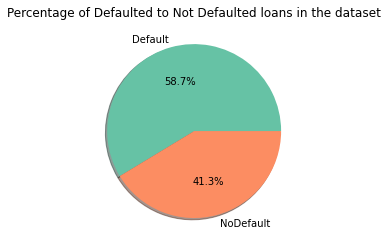

In [145]:
# Data visualization using matlibplot and seaborn libraries
# define Seaborn color palette to use
palette_color = sns.color_palette('Set2')
  
# plotting data on chart
plt.pie(df.LoanStatus.value_counts().values, labels = df.LoanStatus.value_counts().index,
        explode=[0, 0] ,colors = palette_color, autopct ='%.1f%%', shadow = True)
plt.title("Percentage of Defaulted to Not Defaulted loans in the dataset")        
  
# displaying chart
plt.show()

We have 55.3% Defaulted loans

#### Residency of the Defaulters :

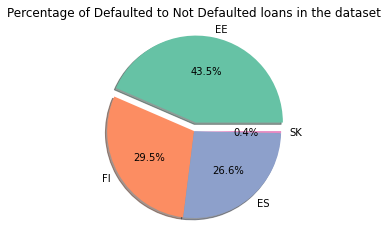

In [146]:
# Data visualization using matlibplot and seaborn libraries
# define Seaborn color palette to use
palette_color = sns.color_palette('Set2')
  
# plotting data on chart
plt.pie(df.Country[df.LoanStatus == 'Default'].value_counts().values, 
        labels = df.Country[df.LoanStatus == 'Default'].value_counts().index,
        explode=[0.1, 0, 0,0] ,colors = palette_color, autopct ='%.1f%%', shadow = True)
plt.title("Percentage of Defaulted to Not Defaulted loans in the dataset")        
  
# displaying chart
plt.show()

- Estonia has the most number of Defaulters.

#### Gender distribution of defaulters :

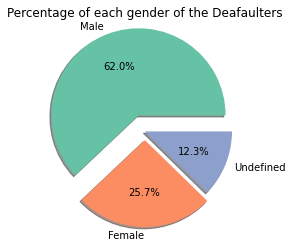

In [147]:
# Data visualization using matlibplot and seaborn libraries
# define Seaborn color palette to use
palette_color = sns.color_palette('Set2')
  
# plotting data on chart
plt.pie(df.Gender[df.LoanStatus == 'Default'].value_counts().values, 
        labels = df.Gender[df.LoanStatus == 'Default'].value_counts().index,
        explode=[0.2, 0.1, 0] ,colors = palette_color, autopct ='%.1f%%', shadow = True)
plt.title("Percentage of each gender of the Deafaulters")        
  
# displaying chart
plt.show()

- We notice that the majority of the defaulters are Males.

#### Check if the most Defaluters are New Credit Customers or not :

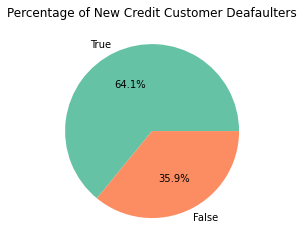

In [148]:
# Data visualization using matlibplot and seaborn libraries
# define Seaborn color palette to use
palette_color = sns.color_palette('Set2')
  
# plotting data on chart
plt.pie(df.NewCreditCustomer[df.LoanStatus == 'Default'].value_counts().values, 
        labels = df.NewCreditCustomer[df.LoanStatus == 'Default'].value_counts().index,
        explode=[0, 0] ,colors = palette_color, autopct ='%.1f%%', shadow = False)
plt.title("Percentage of New Credit Customer Deafaulters")        
  
# displaying chart
plt.show()

- We can see that most of the Defaulters are New Credit Users.

#### Language Code Distribution of the Defaulters :

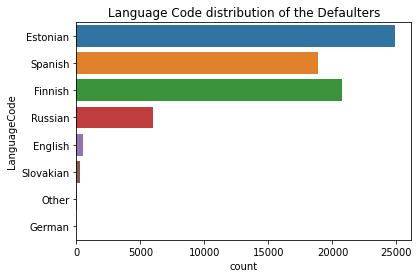

In [149]:
sns.countplot(y = df.LanguageCode[df.LoanStatus == 'Default'])
plt.title('Language Code distribution of the Defaulters');

- It's obvious that Estonian, Finnish, and Spanish-speaking borrowers defaulted most which is but obvious as this peer-to-peer lending platform is basically targeted to European countries.

#### Education wise distribution of defaulters :

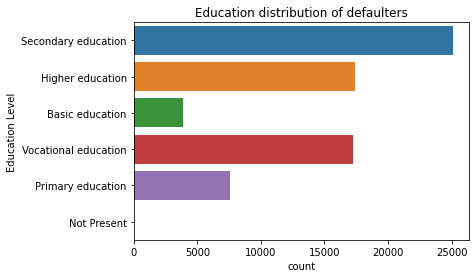

In [150]:
sns.countplot(data=df, y = df.Education[df.LoanStatus == 'Default'])
plt.title('Education distribution of defaulters')
plt.ylabel('Education Level');

- We can notice that borrowers with Secondary education have the largets number of Defaulters, then those with Full time job.

#### Employment Status distribution of the Defaulters :

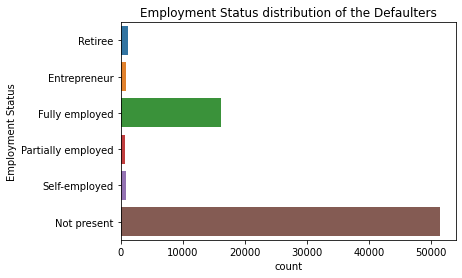

In [151]:
sns.countplot(data=df, y = df.EmploymentStatus[df.LoanStatus == 'Default'])
plt.title('Employment Status distribution of the Defaulters')
plt.ylabel('Employment Status');

#### Marital Status distribution of the Defaulters :

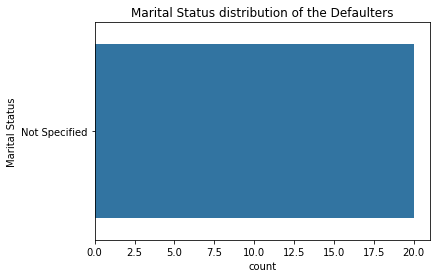

In [152]:
sns.countplot(data=df, y = df.MaritalStatus[df.LoanStatus == 'Default'])
plt.title('Marital Status distribution of the Defaulters')
plt.ylabel('Marital Status');

- we can observe that borrowers having no clear Marital Status are defaulted the most, then those with single marital status. 

#### Distribution of Loan purpose the Defaulters :

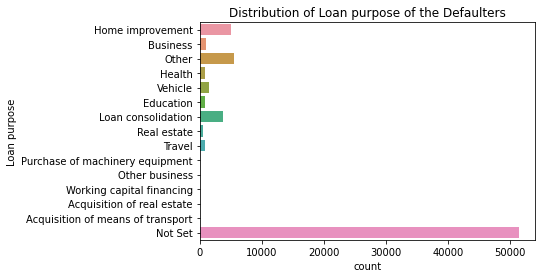

In [153]:
sns.countplot(data=df, y = df.UseOfLoan[df.LoanStatus == 'Default'])
plt.title('Distribution of Loan purpose of the Defaulters')
plt.ylabel('Loan purpose');

-  we can observe that those loans having no clear purpose defaulted most, while others and home improvement purpose are second and third most defaulted loans.



#### Distribution of Employment Duration of the Defaulters :

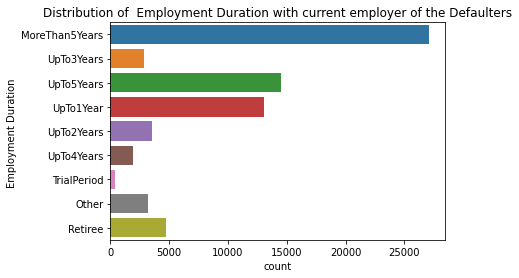

In [154]:
sns.countplot(data=df, y = df.EmploymentDurationCurrentEmployer[df.LoanStatus == 'Default'])
plt.title('Distribution of  Employment Duration with current employer of the Defaulters')
plt.ylabel('Employment Duration ');

- Most defaulters are those who have employment of more than 5 years while the second most defaulted loans come from the borrowers who have employment up to 1 year. 
- That’s really surprising that most experienced professionals defaulted the most.

#### Distribution of Occupation Area of the Defaulters :

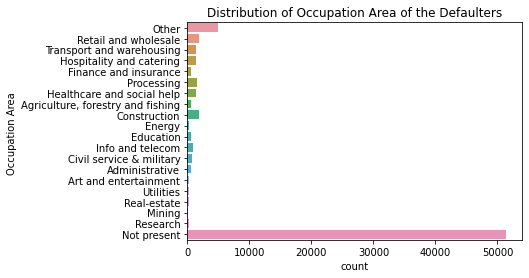

In [155]:
sns.countplot(data=df, y = df.OccupationArea[df.LoanStatus == 'Default'])
plt.title('Distribution of Occupation Area of the Defaulters')
plt.ylabel('Occupation Area ');

- Most defaulters are those who didn't state their Occupation Area.

#### Distribution of Home Ownership Type of the Defaulters :

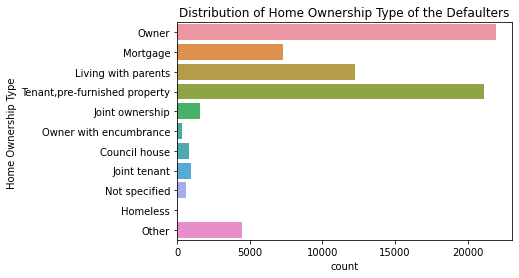

In [156]:
sns.countplot(data=df, y = df.HomeOwnershipType[df.LoanStatus == 'Default'])
plt.title('Distribution of Home Ownership Type of the Defaulters')
plt.ylabel('Home Ownership Type ');

- Most defaulters are those who have a home, while the second most defaulted loans come from the borrowers who have Tenant, pre-furnished property.
- That’s really surprising that borrower having a home are defaulted the most.

#### Distribution of Ratings of the Defaulters :

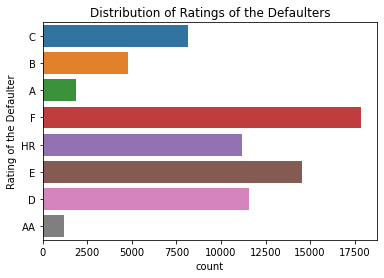

In [157]:
sns.countplot(data=df, y = df.Rating[df.LoanStatus == 'Default'])
plt.title('Distribution of Ratings of the Defaulters')
plt.ylabel('Rating of the Defaulter');

- Borrower with a rating F is defaulted the most.

#### Distribution of Credit Score EsMicroL of the Defaulters :

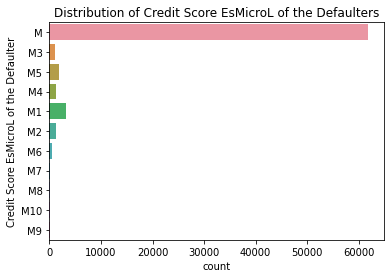

In [158]:
sns.countplot(data=df, y = df.CreditScoreEsMicroL[df.LoanStatus == 'Default'])
plt.title('Distribution of Credit Score EsMicroL of the Defaulters')
plt.ylabel('Credit Score EsMicroL of the Defaulter');

- Borrower with a Credit Score EsMicroL M is defaulted the most.

## Numerical features distribution :

In [159]:
df.select_dtypes(int).columns

Index(['LoanNumber', 'BidsPortfolioManager', 'BidsApi', 'Age', 'LoanDuration',
       'ExistingLiabilities', 'RefinanceLiabilities'],
      dtype='object')

In [160]:
df.select_dtypes(float).columns

Index(['BidsManual', 'AppliedAmount', 'Amount', 'Interest', 'MonthlyPayment',
       'IncomeTotal', 'LiabilitiesTotal', 'DebtToIncome', 'FreeCash',
       'RecoveryStage', 'PrincipalPaymentsMade',
       'InterestAndPenaltyPaymentsMade', 'PrincipalBalance',
       'InterestAndPenaltyBalance', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan'],
      dtype='object')

#### Age distribution of the Defaulters :

In [161]:
df.Age[df.LoanStatus=='Default'].describe()

count    71253.000000
mean        40.665656
std         12.568481
min          0.000000
25%         31.000000
50%         39.000000
75%         50.000000
max         77.000000
Name: Age, dtype: float64

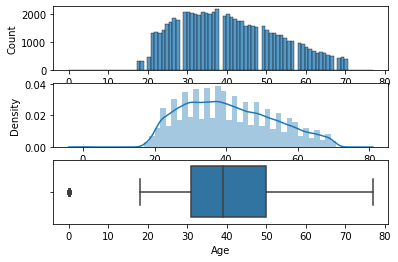

In [162]:
fig, axs = plt.subplots(nrows= 3)

sns.histplot(df.Age[df.LoanStatus=='Default'], ax=axs[0]);
sns.distplot(df.Age[df.LoanStatus=='Default'], ax=axs[1])
sns.boxplot(df.Age[df.LoanStatus=='Default'], ax=axs[2]);


- Mean Age = Median Age which is about 40 years
- The data is almost Symmetric.
- There is only one Outlier


#### Monthly Payment distribution of the Defaulters :

In [163]:
df.MonthlyPayment.describe()

count    121461.000000
mean        122.209744
std         114.251642
min           0.000000
25%          39.190000
50%         106.730000
75%         155.730000
max        2368.540000
Name: MonthlyPayment, dtype: float64

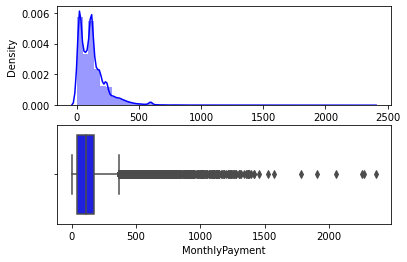

In [164]:
fig, axs = plt.subplots(nrows=2)
sns.distplot(df.MonthlyPayment[df.LoanStatus=='Default'], ax=axs[0], color='blue')
sns.boxplot(df.MonthlyPayment[df.LoanStatus=='Default'], ax=axs[1], color='blue');

- Mean value is 130, it's smaller and mean that the monthly payments of the Defaulters are smaller.
- We notice that the data is right skewed. This means that the smaller values occur in the data with higher frequency and the larger values occur with comparatively lesser frequency, so the Defaulters have a small monthly payments.
- There are a large number of Outliers above the upper limit.

#### AppliedAmount & Amount distribution of the Defaulters :

In [165]:
df.Amount.describe()

count    121461.000000
mean       2522.255902
std        2157.411853
min           6.390000
25%         740.000000
50%        2125.000000
75%        3580.000000
max       10632.000000
Name: Amount, dtype: float64

In [166]:
df.AppliedAmount.describe()

count    121461.000000
mean       2723.155439
std        2371.562360
min          10.000000
25%         740.000000
50%        2125.000000
75%        4150.000000
max       10632.000000
Name: AppliedAmount, dtype: float64

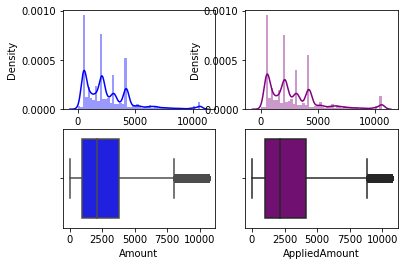

In [167]:
fig, axs = plt.subplots(nrows=2, ncols= 2)
sns.distplot(df.Amount[df.LoanStatus=='Default'], ax=axs[0,0], color='blue')
sns.boxplot(df.Amount[df.LoanStatus=='Default'], ax=axs[1,0], color='blue');

sns.distplot(df.AppliedAmount[df.LoanStatus=='Default'], ax=axs[0,1], color='purple')
sns.boxplot(df.AppliedAmount[df.LoanStatus=='Default'], ax=axs[1,1], color='purple');


- Mean value of The amount of money the Defaulter applied for originally is 2746, and what he/she recieves is 2472
- Data is right skewed in both.
- There is a large number of Outliers in both.

#### Previous Repayments Before Loan distribution of the Defaulters :

In [168]:
df.PreviousRepaymentsBeforeLoan.describe()

count    121461.00000
mean        929.76239
std        1666.53111
min           0.00000
25%          29.15000
50%         754.93000
75%         929.76239
max       34077.42000
Name: PreviousRepaymentsBeforeLoan, dtype: float64

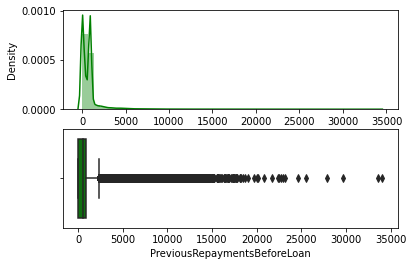

In [169]:
fig, axs = plt.subplots(nrows=2)
sns.distplot(df.PreviousRepaymentsBeforeLoan[df.LoanStatus=='Default'], ax=axs[0], color='green')
sns.boxplot(df.PreviousRepaymentsBeforeLoan[df.LoanStatus=='Default'], ax=axs[1], color='green');

- Mean value of the repaid money by the defaulters before the loan is  861.138387
- Data very skewed to the right and this means that the defaulters repaid small amount of money with a mean value about 861
- There are alot of Ouliers.

#### We can see the relationship between features of the Defaluters :

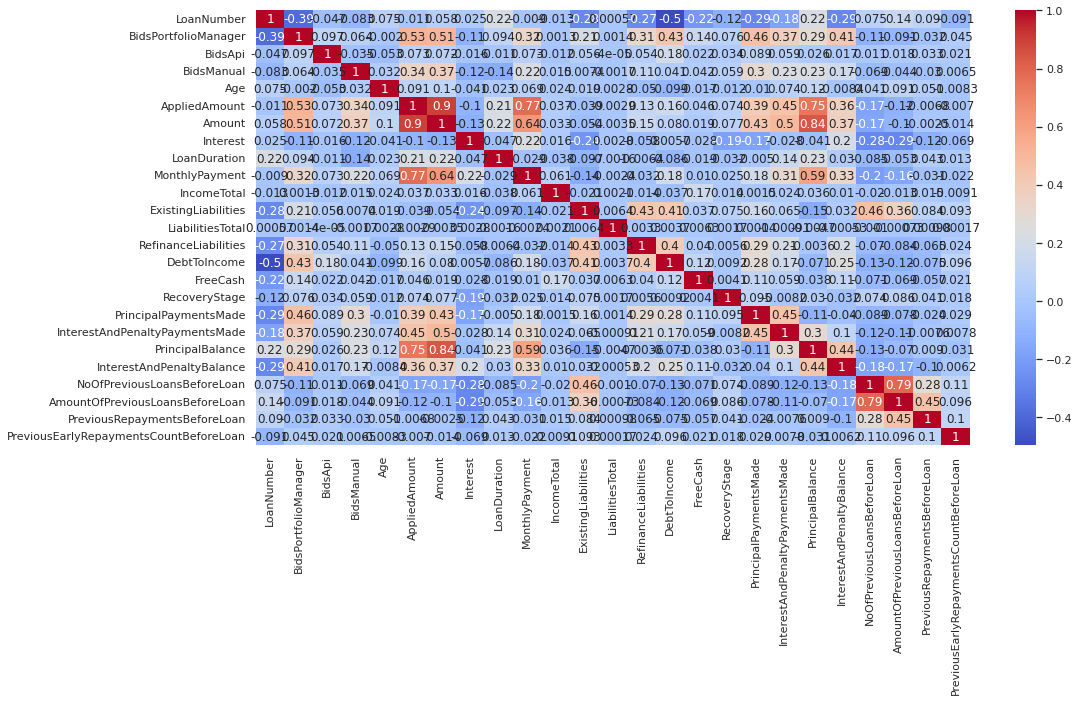

In [170]:
# Let's produce Heat Map
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df[df.LoanStatus == 'Default'].corr(), annot = True, fmt='.2g',cmap= 'coolwarm');

We notice that :
- There are featues that are positively correlated to each other.
- There are features that are negatively correlated to each other.
- Mostly, features are not correalted to each others.

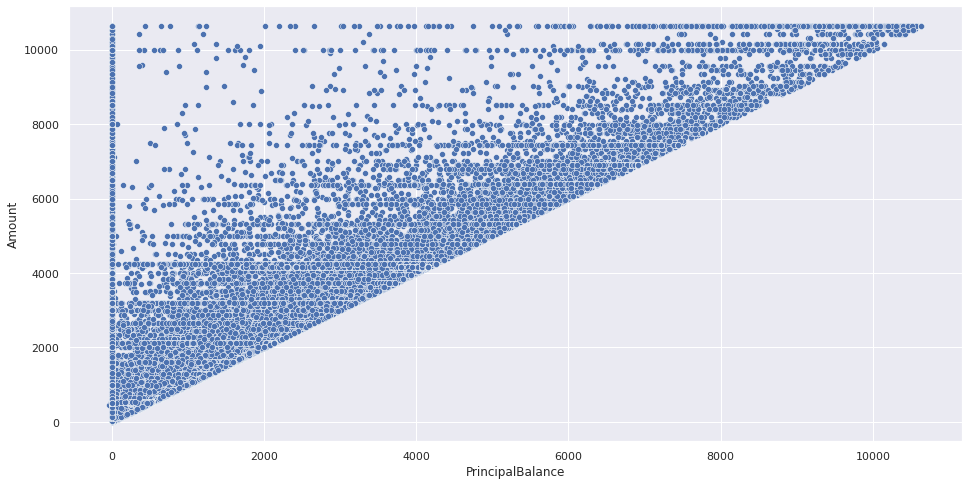

In [171]:
 # For Example : -  Amount and PriniaplBalance  
sns.scatterplot(x = df.PrincipalBalance, y = df.Amount)
plt.show();

## Feature Engineering:
<ul>
<li><a href="#intro">Handling Null values</a></li>
<li><a href="#wrangling">Handling outliers</a></li>
<li><a href="#wrangling">Feature Selection</a></li>
<li><a href="#eda">Categorical Features Encoding</a></li>
<li><a href="#conclusions">Feature scaling</a></li>
<li><a href="#conclusions">Dimensionality Reduction using PCA</a></li>
<li><a href="#conclusions">Building Models</a></li>
</ul>

### 1. Handling Null values:
- We have already handled them in the previous work.

### 2. Handling outliers:

###### What are the criteria to identify an outlier?

a - Data point that falls outside of 1.5 times of an interquantile range above the 3rd quartile and below the 1st quartile.

b - Data point that falls outside of 3 standard deviations. We can use a Z-score, and if the Z-score falls outside of 2 standard deviation. 

###### How can we find the outliers?
- Using Scatter plots. 
- Using Box plots.
- Using Z-score.
- Using the interquartile range (IQR).

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<AxesSubplot:xlabel='PreviousRepaymentsBeforeLoan'>

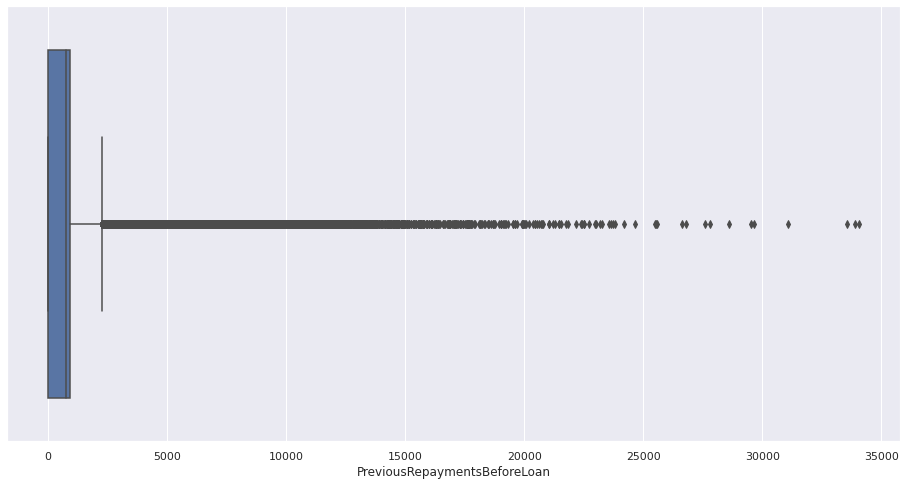

In [172]:
sns.boxplot(df.PreviousRepaymentsBeforeLoan)

In [173]:
# Let's compute IQR for each numerical feature
df_IQR = df[df.select_dtypes([float, int]).columns].quantile(.75) - df[df.select_dtypes([float, int]).columns].quantile(.25)
df_IQR 

LoanNumber                                871978.00000
BidsPortfolioManager                        1084.00000
BidsApi                                        5.00000
BidsManual                                   637.00000
Age                                           19.00000
AppliedAmount                               3410.00000
Amount                                      2840.00000
Interest                                      23.08000
LoanDuration                                  24.00000
MonthlyPayment                               116.54000
IncomeTotal                                 1050.00000
ExistingLiabilities                            3.00000
LiabilitiesTotal                             566.52000
RefinanceLiabilities                           0.00000
DebtToIncome                                   6.26000
FreeCash                                      11.20000
RecoveryStage                                  1.00000
PrincipalPaymentsMade                       1445.33000
InterestAn

In [174]:
# Let's compute maximum and minimum limits
df_Max =  df[df.select_dtypes([float, int]).columns].quantile(.75) + (1.5*df_IQR)
df_Min =  df[df.select_dtypes([float, int]).columns].quantile(.25) - (1.5*df_IQR)
df_Max

LoanNumber                                2.772313e+06
BidsPortfolioManager                      2.855000e+03
BidsApi                                   1.250000e+01
BidsManual                                1.661500e+03
Age                                       7.750000e+01
AppliedAmount                             9.265000e+03
Amount                                    7.840000e+03
Interest                                  7.990000e+01
LoanDuration                              9.600000e+01
MonthlyPayment                            3.305400e+02
IncomeTotal                               3.525000e+03
ExistingLiabilities                       8.500000e+00
LiabilitiesTotal                          1.471300e+03
RefinanceLiabilities                      0.000000e+00
DebtToIncome                              1.565000e+01
FreeCash                                  2.800000e+01
RecoveryStage                             3.500000e+00
PrincipalPaymentsMade                     3.757995e+03
InterestAn

###### We can Handling the outliers of each numerical feature :

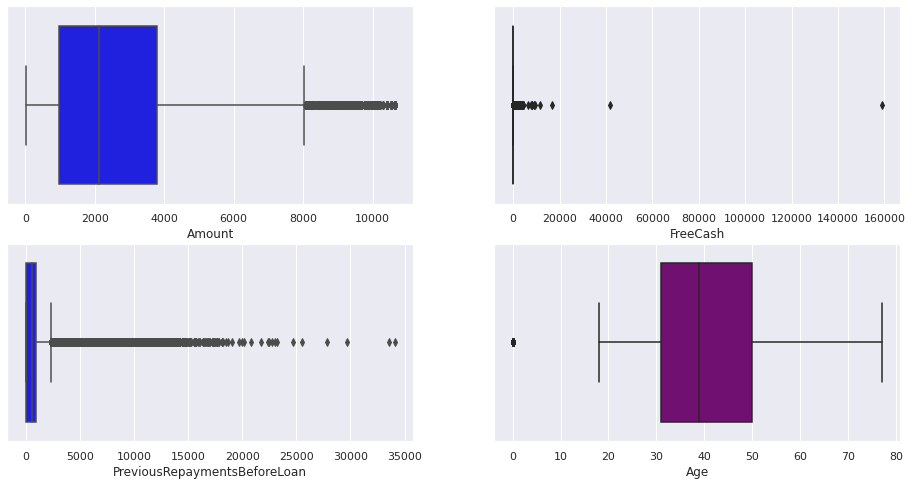

In [175]:
#Box plots before handling outliers
fig, axs = plt.subplots(nrows=2, ncols= 2)
sns.boxplot(df.Amount[df.LoanStatus=='Default'], ax=axs[0,0], color='blue')
sns.boxplot(df.PreviousRepaymentsBeforeLoan[df.LoanStatus=='Default'], ax=axs[1,0], color='blue');

sns.boxplot(df.FreeCash[df.LoanStatus=='Default'], ax=axs[0,1], color='purple')
sns.boxplot(df.Age[df.LoanStatus=='Default'], ax=axs[1,1], color='purple');

In [176]:
df.select_dtypes([float, int]).columns

Index(['LoanNumber', 'BidsPortfolioManager', 'BidsApi', 'BidsManual', 'Age',
       'AppliedAmount', 'Amount', 'Interest', 'LoanDuration', 'MonthlyPayment',
       'IncomeTotal', 'ExistingLiabilities', 'LiabilitiesTotal',
       'RefinanceLiabilities', 'DebtToIncome', 'FreeCash', 'RecoveryStage',
       'PrincipalPaymentsMade', 'InterestAndPenaltyPaymentsMade',
       'PrincipalBalance', 'InterestAndPenaltyBalance',
       'NoOfPreviousLoansBeforeLoan', 'AmountOfPreviousLoansBeforeLoan',
       'PreviousRepaymentsBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan'],
      dtype='object')

In [177]:
col_IQR = df['Age'].quantile(.75) - df['Age'].quantile(.25)
col_Max =  df['Age'].quantile(.75) + (1.5*col_IQR)
col_Max

77.5

Now we will replace outliers of each column with Lower and Upper bounds of each column:

In [178]:
# Loop for replacing outliers above upper bound with the upper bound value:
for column in df.select_dtypes([float, int]).columns :
   
    col_IQR = df[column].quantile(.75) - df[column].quantile(.25)
    col_Max =  df[column].quantile(.75) + (1.5*col_IQR)
    df[column][df[column] > col_Max] =  col_Max

In [180]:
# Loop for replacing outliers under lower bound with the lower bound value:
for column in df.select_dtypes([float, int]).columns :
    col_IQR = df[column].quantile(.75) - df[column].quantile(.25)
    col_Min =  df[column].quantile(.25) - (1.5*col_IQR)
    df[column][df[column] < col_Min] =  col_Min

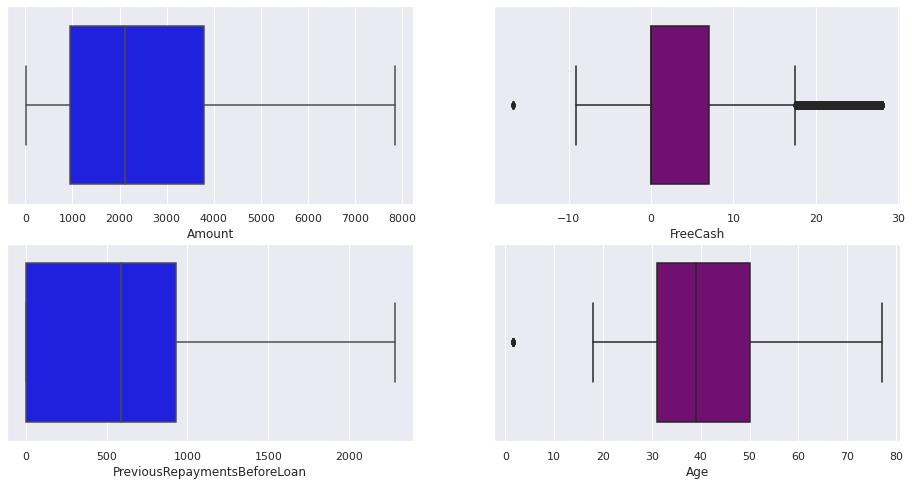

In [181]:
# Check, boxplot after handling outliers:
fig, axs = plt.subplots(nrows=2, ncols= 2)
sns.boxplot(df.Amount[df.LoanStatus=='Default'], ax=axs[0,0], color='blue')
sns.boxplot(df.PreviousRepaymentsBeforeLoan[df.LoanStatus=='Default'], ax=axs[1,0], color='blue');

sns.boxplot(df.FreeCash[df.LoanStatus=='Default'], ax=axs[0,1], color='purple')
sns.boxplot(df.Age[df.LoanStatus=='Default'], ax=axs[1,1], color='purple');


## 4. Feature Encoding

###### Let's divide our features to "Target" feature and "Independnt features" :

In [183]:
y = df.LoanStatus
x = df.drop(columns = ['LoanStatus'])


In [184]:
x

,LoanId,LoanNumber,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,VerificationType,LanguageCode,Age,Gender,Country,AppliedAmount,Amount,Interest,LoanDuration,MonthlyPayment,UseOfLoan,Education,MaritalStatus,EmploymentStatus,EmploymentDurationCurrentEmployer,OccupationArea,HomeOwnershipType,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,DebtToIncome,FreeCash,RecoveryStage,Rating,Restructured,CreditScoreEsMicroL,PrincipalPaymentsMade,InterestAndPenaltyPaymentsMade,PrincipalBalance,InterestAndPenaltyBalance,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan
0,66AE108B-532B-4BB3-BAB7-0019A46412C1,483449,970,12.5,5.0,BO965519,False,Income and expenses verified,Estonian,53.0,Female,EE,2125.0,2125.0,20.97,60,62.05,Home improvement,Secondary education,NaN,Retiree,MoreThan5Years,Other,Owner,354.0,8.0,485.09,0,15.65,10.92,2.0,C,False,M,969.160,1187.91,1155.84,433.600,1.0,500.0,590.950000,0.0
1,D152382E-A50D-46ED-8FF2-0053E0C86A70,378148,1295,0.0,1661.5,BOA9K172A,False,Income unverified,Estonian,50.0,Female,EE,3000.0,3000.0,17.12,60,84.75,Business,Higher education,NaN,Entrepreneur,MoreThan5Years,Retail and wholesale,Owner,900.0,4.0,736.45,0,15.65,28.00,2.0,B,False,M,563.590,360.07,2436.41,2291.820,1.0,1800.0,445.260000,0.0
2,87342E13-66CB-483F-833A-007953E50C78,451831,2700,12.5,1661.5,BO7971663,True,Income and expenses verified,Estonian,44.0,Male,EE,9265.0,7840.0,13.67,60,268.57,Business,Secondary education,NaN,Entrepreneur,UpTo3Years,Transport and warehousing,Mortgage,1200.0,7.0,905.00,0,15.65,28.00,2.0,A,False,M,3757.995,1635.59,0.00,0.000,0.0,0.0,0.000000,0.0
3,87227056-6BF9-410C-98D1-008F788E122A,349381,1115,0.0,385.0,BO76151K3,True,Income verified,Spanish,42.0,Male,ES,1500.0,1500.0,40.40,60,63.53,Home improvement,Basic education,NaN,Fully employed,UpTo5Years,Other,Living with parents,863.0,1.0,350.00,0,7.36,28.00,1.0,F,False,M3,464.730,355.92,1035.27,2833.830,0.0,0.0,0.000000,0.0
4,2DDE6336-E466-4624-A337-00A0ED1A1468,443082,305,0.0,785.0,BOK423A63,True,Income and expenses verified,Spanish,34.0,Female,ES,1595.0,1090.0,68.39,48,101.19,Other,Secondary education,NaN,Retiree,UpTo1Year,Other,"Tenant,pre-furnished property",697.0,5.0,940.00,0,15.65,28.00,1.0,HR,False,M5,0.010,0.00,1089.99,3295.025,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179230,D9E714C3-B9B8-4FD1-B1AD-FF55B3AE8A8F,323749,2000,0.0,0.0,BO6492A4A,True,Income unverified,Finnish,38.0,Female,FI,2000.0,2000.0,33.79,60,76.11,Vehicle,Vocational education,NaN,Fully employed,UpTo5Years,Other,"Tenant,pre-furnished property",2300.0,3.0,830.00,0,9.40,28.00,2.0,E,False,M,0.000,0.00,2000.00,3295.025,0.0,0.0,0.000000,0.0
179231,09999223-3D69-42E3-BAAA-FF7F312AB236,468598,2855,12.5,1155.0,BO542A57A,False,Income and expenses verified,Finnish,37.0,Male,FI,7440.0,7440.0,24.52,60,232.40,Loan consolidation,Secondary education,NaN,Fully employed,MoreThan5Years,Healthcare and social help,"Tenant,pre-furnished property",2172.0,8.5,1471.30,0,15.65,5.51,NaN,D,False,M,3757.995,1635.59,0.00,0.000,2.0,2500.0,986.780000,0.0
179232,370193A5-D19C-4A99-97F7-FF95BEA52731,462572,430,0.0,1055.0,BO65A965,False,Income unverified,Spanish,37.0,Male,ES,1595.0,1485.0,64.51,60,93.08,Other,Vocational education,NaN,Fully employed,MoreThan5Years,Administrative,Mortgage,1550.0,7.0,1471.30,0,15.65,28.00,NaN,HR,False,M4,1485.000,186.41,0.00,0.000,3.0,2425.0,2280.680975,0.0
179233,98D9FCCE-0FD7-420E-9F7F-FFA960669E8B,396046,2855,0.0,0.0,BO9577433,True,Income unverified,Russian,58.0,Female,EE,3000.0,3000.0,21.62,60,88.71,Vehicle,Vocational education,NaN,Fully employed,UpTo3Years,Other,Owner,350.0,3.0,359.00,0,15.65,11.29,NaN,C,False,M,3000.000,1635.59,0.00,0.000,0.0,0.0,0.000000,0.0


In [185]:
# Let's perform categorical features encoding:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

In [186]:
# Target_feature Encoding:
y = LE.fit_transform(y)

In [188]:
# Ind_features Encoding:
for feature in x.select_dtypes([object, bool]).columns:
    x[feature]= LE.fit_transform(x[feature])

In [199]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 121461 entries, 0 to 179234
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   LoanId                                  121461 non-null  int64  
 1   LoanNumber                              121461 non-null  int64  
 2   BidsPortfolioManager                    121461 non-null  int64  
 3   BidsApi                                 121461 non-null  float64
 4   BidsManual                              121461 non-null  float64
 5   UserName                                121461 non-null  int64  
 6   NewCreditCustomer                       121461 non-null  int64  
 7   VerificationType                        121461 non-null  int64  
 8   LanguageCode                            121461 non-null  int64  
 9   Age                                     121461 non-null  float64
 10  Gender                                  1214

In [190]:
y

array([0, 0, 0, ..., 1, 1, 0])

## 3. Feature Selection
There are many types and techniques for feature selection such as:
1. Filter
- Correlation.
- Variance threshold.
- Chi-squared.
- Anova.
- Information gain.
2. Wrapper 
- Recursive Feature Elimination (RFE).
3. Embedded
- L1 and L2 Regularization Methods.



Now we will use correlation filter selection technique:

- Highly correlated features will be considered duplicated features while using the machine learning model, so we should drop them(drop one and leave the another).

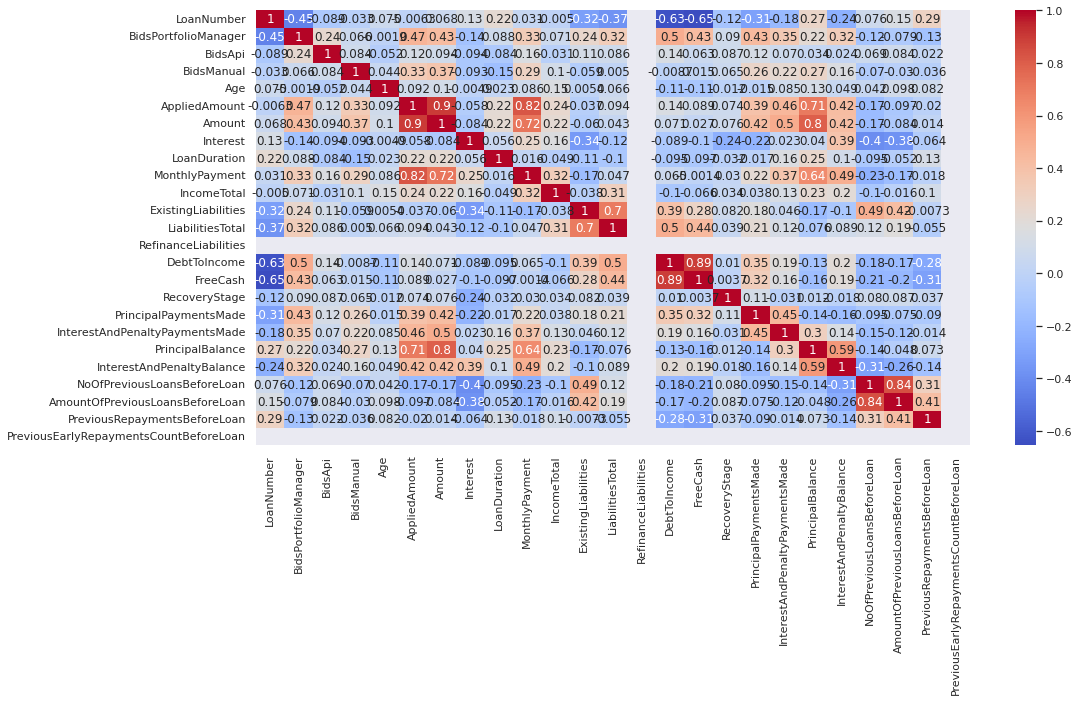

In [191]:
# Let's produce Heat Map
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df[df.LoanStatus == 'Default'].corr(), annot = True, fmt='.2g',cmap= 'coolwarm');

In [192]:
# A function to select highly correlated features.
def Correlation(dataset, threshold): 
    correltated_features = set() # as a container of highly correlated features
    correlation_matrix = dataset.corr()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > threshold:
                column_name = correlation_matrix.columns[i]
                correltated_features.add(column_name)
    return correltated_features

In [209]:
# let's selected features with a correlation factor > 0.8
Correlation(x, 0.8)

{'FreeCash', 'MonthlyPayment', 'Rating'}

In [213]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 121461 entries, 0 to 179234
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   LoanId                                  121461 non-null  int64  
 1   LoanNumber                              121461 non-null  int64  
 2   BidsPortfolioManager                    121461 non-null  int64  
 3   BidsApi                                 121461 non-null  float64
 4   BidsManual                              121461 non-null  float64
 5   UserName                                121461 non-null  int64  
 6   NewCreditCustomer                       121461 non-null  int64  
 7   VerificationType                        121461 non-null  int64  
 8   LanguageCode                            121461 non-null  int64  
 9   Age                                     121461 non-null  float64
 10  Gender                                  1214

In [212]:
# Now we can drop these features from our dataset
x.drop(columns= ['Amount', 'AmountOfPreviousLoansBeforeLoan', 'NoOfPreviousLoansBeforeLoan'], inplace = True )

KeyError: "['Amount' 'AmountOfPreviousLoansBeforeLoan' 'NoOfPreviousLoansBeforeLoan'] not found in axis"

Now we will use Scikit learn library for feature selection

In [220]:
import numpy as np
import pandas as pd

print("Jumlah NaN di setiap kolom:")
print(x.isna().sum())

print("\nApakah ada inf di data?")
print(np.isinf(x).sum())



Jumlah NaN di setiap kolom:
LoanId                                        0
LoanNumber                                    0
BidsPortfolioManager                          0
BidsApi                                       0
BidsManual                                    0
UserName                                      0
NewCreditCustomer                             0
VerificationType                              0
LanguageCode                                  0
Age                                           0
Gender                                        0
Country                                       0
AppliedAmount                                 0
Interest                                      0
LoanDuration                                  0
MonthlyPayment                                0
UseOfLoan                                     0
Education                                     0
MaritalStatus                                 0
EmploymentStatus                              0
EmploymentDu

In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [224]:
# Mengisi NaN dengan median (atau mean, tergantung data)
x = x.fillna(x.median())


In [226]:
x = x.replace([np.inf, -np.inf], np.nan)
x = x.fillna(x.median())



In [227]:
# using mutual_info_classif to choose our features
features = SelectKBest(mutual_info_classif, k=15)
# Selected features
Selected_features =   features.fit_transform(x, y)

In [228]:
# Display selected features
x.columns[features.get_support()]

Index(['LoanNumber', 'UserName', 'LanguageCode', 'Country', 'AppliedAmount',
       'Interest', 'LoanDuration', 'MonthlyPayment', 'RecoveryStage', 'Rating',
       'Restructured', 'PrincipalPaymentsMade',
       'InterestAndPenaltyPaymentsMade', 'PrincipalBalance',
       'InterestAndPenaltyBalance'],
      dtype='object')

## 5. Feature Scaling

There are two major types of feature scaling :
-  Standardization.
- Normalization.

We can use StandardScalar to scale our data:
- StandardScaler is used to resize the distribution of values ​​so that the mean of the observed values ​​is 0 and the standard deviation is 1.
- The values will lie be between -1 and 1.

In [229]:
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler

In [230]:
Standard_Scalar = StandardScaler()

In [232]:
Selected_features = Standard_Scalar.fit_transform(Selected_features)

In [233]:
Selected_features

array([[-0.90077323,  0.68352818, -0.77008317, ...,  1.40990046,
        -0.02422045, -0.31279489],
       [-1.0821062 ,  1.08158916, -0.77008317, ..., -0.1884831 ,
         0.80366964,  1.27478161],
       [-0.95522082,  0.43322508, -0.77008317, ...,  2.27427564,
        -0.77147245, -0.68324251],
       ...,
       [-0.93672435,  0.02905144,  1.75305005, ..., -0.52378375,
        -0.77147245, -0.68324251],
       [-1.05128506,  0.6593937 ,  0.91200565, ...,  2.27427564,
        -0.77147245, -0.68324251],
       [-1.08780272,  1.53998636, -0.77008317, ..., -0.58832999,
        -0.77147245, -0.68324251]])

## 6. Feature Extraction and Dimensionality-reduction using (PCA) 


Principal component analysis, or PCA, is a dimensionality-reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information. 

The idea of PCA is simple — reduce the number of variables of a data set, while preserving as much information as possible.

PCA steps:
- Feature Scaling.
- Covariance Matrix computation.
- Compute the eigenvectors and eigenvalues of the covariance matrix to identify the principal components.
- Feature Vector. 
- Recast the Data Along the Principal Components Axes.

In [238]:
# importing PCA class
from sklearn.decomposition import PCA

In [239]:
# Create a PCA object
pca = PCA(n_components = 2) 

In [240]:
# Let's fit our data using PCA
Selected_features_pca =  pca.fit_transform(Selected_features)


In [241]:
Selected_features_pca.shape

(121461, 2)

In [242]:
Selected_features_pca.shape

(121461, 2)

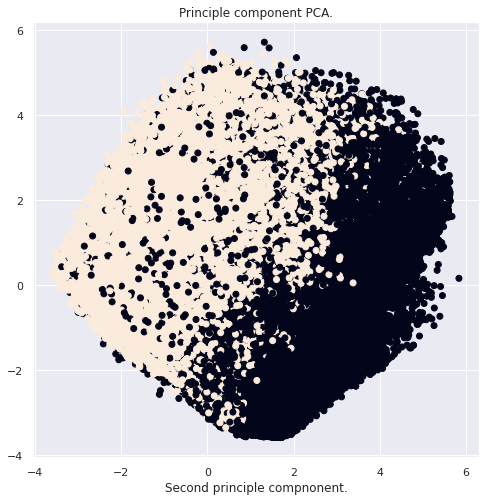

In [243]:
plt.figure(figsize=(8, 8))
plt.scatter(Selected_features_pca[:,0], Selected_features_pca[:,1], c = y)
plt.title('Principle component PCA.')
plt.xlabel("First principle compnonent.")
plt.xlabel("Second principle compnonent.")
plt.show();

Explained Variance:
- Explained variance is a statistical measure of how much variation in a dataset can be attributed to each of the principal components (eigenvectors) generated by the principal component analysis (PCA) method.
- it tells us how much of the total variance is “explained” by each component.
- the larger the variance explained by a principal component, the more important that component is. 
- The amount of variance explained by each direction is called the “explained variance.
- Explained variance can be used to choose the number of dimensions to keep in a reduced dataset. It can also be used to assess the quality of a machine learning model. In general, a model with high explained variance will have good predictive power, while a model with low explained variance may not be as accurate.
- Explained variance can also be used to compare different PCA models. For example, if we compare two models that both reduce a dataset from 10 dimensions to 2, but one explains 80% of the variance and the other explains 95% of the variance, we would say that the latter model is better at representing the data.


- Example : While you can convert 4-d space to 2-d space, you lose some of variance (information), by using explained_variance_ratio_, you can see the first principle component contains say 72.77% of the variance and the second principle component contains say  23.03% of the variance. Together the two compnenets contain 95.80% of the information.

In [244]:
pca.explained_variance_ratio_

array([0.23542895, 0.16455372])

In [245]:
# Percentage of information we have after apllying 2-d PCA
sum(pca.explained_variance_ratio_) * 100

39.998267031725455

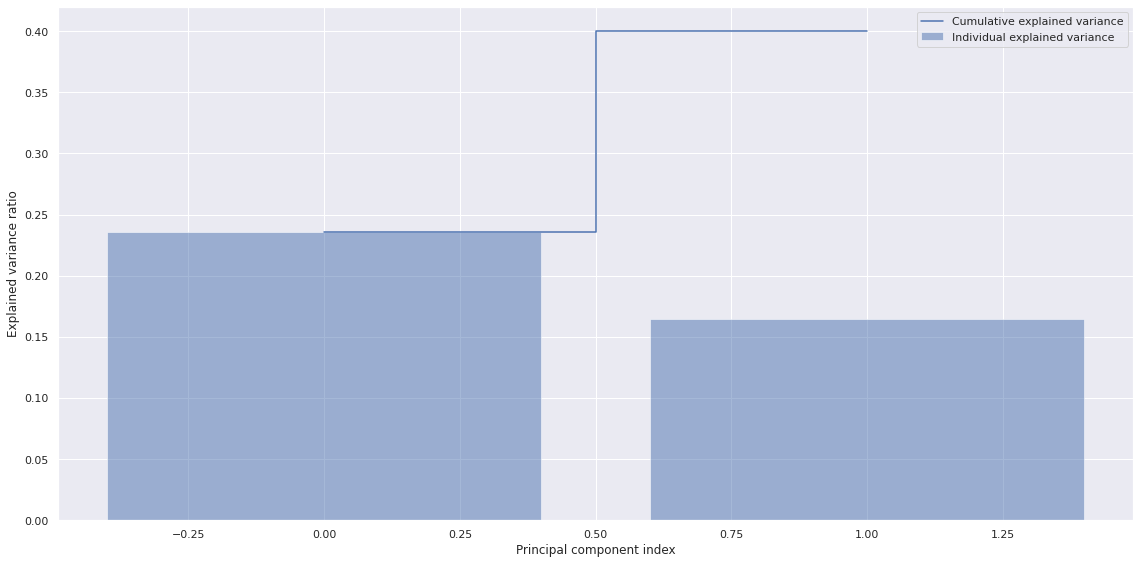

In [246]:
exp_var_pca = pca.explained_variance_ratio_
# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
#
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
#
# Create the visualization plot
#
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

- After trying the PCA with different parameters we didn't get a good accuracy, so we decided to not use it in our work.

## Building Our Models

- Now we will split our data into training and testing sets and make the data ready for the machine learning algorithm.
- We can use :
        - Train Test Split.
        -  K-Fold Cross-Validation.

In [247]:
# Let's use Train Test Split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Selected_features, y, random_state=42, train_size = 0.8)

### We will use two models in our work:
#### 1- Logistic Regression model
#### 2- Random Forrest model

#### 1. Logistic Regression Model

In [248]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [249]:
# Let's make LogisticRegression and RandomForestClassifier object
LR = LogisticRegression()

In [250]:
# Let's fit the model on our data
LR.fit(X_train, y_train)

LogisticRegression()

In [251]:
# Let's fit the model on our data
LR.fit(X_train, y_train)

LogisticRegression()

In [252]:
# Let's make predictions
y_predict = LR.predict(X_test)

 Logistic Regression Model Evaluation

In [255]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

In [256]:
# accuracy_score of LogisticResgression model
accuracy_score(y_test, y_predict)

0.9058988185897172

In [257]:
roc_auc_score(y_test, y_predict)

0.9107852722173931

In [258]:
# confusion matrix
confusion_matrix(y_test, y_predict)

array([[12679,  1667],
       [  619,  9328]])

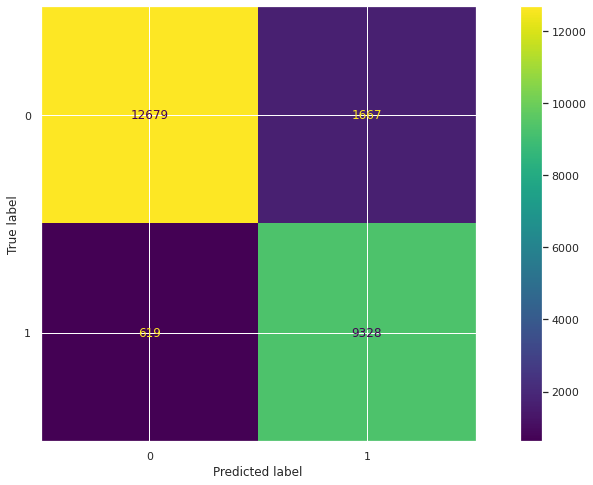

In [259]:
# plot confusion matrix 
plot_confusion_matrix(LR, X_test, y_test);

- Let's perform hyperparameter tuning for the logistic regression to increase the accuracy

In [ ]:
# example of grid searching key hyperparametres for logistic regression
'''from sklearn.model_selection import GridSearchCV
# define models and parameters
param_grid = [    
    {'penalty' : ['l1', 'l2', 'elasticnet'],
    'C' : np.logspace(-4, 4, 20),
    'solver' : ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter' : [100, 1000,2500, 5000]
    }
]'''

In [ ]:
#grid_result = GridSearchCV(logModel, param_grid = param_grid, cv = 3, verbose=True, n_jobs=-1)3

In [ ]:
#grid_result.best_params_

#### 2. Random Forest Classifier Model

- Random forest is a Supervised Machine Learning Algorithm that is used widely in Classification and Regression problems. It builds decision trees on different samples and takes their majority vote for classification and average in case of regression.

- One of the most important features of the Random Forest Algorithm is that it can handle the data set containing continuous variables as in the case of regression and categorical variables as in the case of classification. It performs better results for classification problems.

In [260]:
# Let's use Train Test Split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Selected_features, y, random_state=42, train_size = 0.8)

In [261]:
# Import Logistic Regression model
from sklearn.ensemble import RandomForestClassifier

In [262]:
# Let's make LogisticRegression and RandomForestClassifier object
RFC = RandomForestClassifier()

In [263]:
# Let's fit the model on our data
RFC.fit(X_train, y_train)

RandomForestClassifier()

In [265]:
# Let's make predictions
y_predict = RFC.predict(X_test)

##### Random Forst Model Evaluation

In [266]:
# accuracy_score of LogisticResgression model
accuracy_score(y_test, y_predict)

0.9581360885851892

In [267]:
roc_auc_score(y_test, y_predict)

0.9613023330076284

In [268]:
# confusion matrix
confusion_matrix(y_test, y_predict)

array([[13540,   806],
       [  211,  9736]])

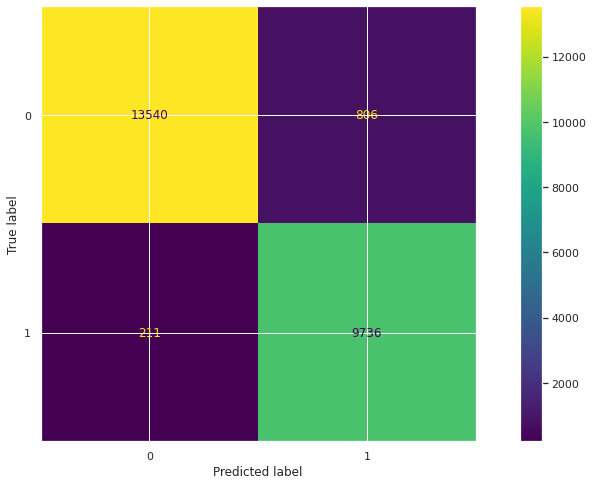

In [269]:
# plot confusion matrix 
plot_confusion_matrix(RFC, X_test, y_test);

### Building Models Conclusion:
#### By using the two models with the same features, we discovered that the Random Forest Classifier model gives accuracy better than the Logistic Regression model